In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime
from scipy import stats as sp_stats
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

In [2]:
US_EQUITY  = ['VIOV', 'MTUM', 'VBR']
ETF_GLOBAL = ['VEA', 'VWO', 'AGG', 'BNDX', 'GLD', 'VNQ', 'BTC-USD']
STOCKS     = ['MC.PA', 'ASML', 'NESN.SW', 'SIE.DE']
BENCHMARK  = ['VT', 'BNDW', 'AOR']
# BIL = T-Bills proxy for Sofia's 5% cash constraint
CASH_PROXY = ['BIL']
ALL_TICKERS = list(set(US_EQUITY + ETF_GLOBAL + STOCKS + BENCHMARK + CASH_PROXY))
START = '2013-01-01'
END   = datetime.today().strftime('%Y-%m-%d')
raw = yf.download(ALL_TICKERS, start=START, end=END, auto_adjust=True, progress=True)['Close']
print(raw.shape)
print(raw.isna().sum().sort_values(ascending=False))

[*********************100%***********************]  18 of 18 completed

(4708, 18)
Ticker
BNDW       2770
BNDX       1445
MTUM       1413
NESN.SW    1350
VT         1340
VNQ        1340
VIOV       1340
VEA        1340
VBR        1340
AGG        1340
AOR        1340
GLD        1340
BIL        1340
ASML       1340
VWO        1340
SIE.DE     1311
MC.PA      1283
BTC-USD     441
dtype: int64


## 1. Investment Policy Statement (IPS)


In [3]:
from IPython.display import Markdown, display

ips = '''
| Attribute | Detail |
|---|---|
| **Investor profile** | Individual — Private wealth |
| **Existing holding** | CHF 180,000 in AstraZeneca (Large Cap Healthcare, 3-year lock-up) |
| **Horizon** | Long-term — 33 years (retirement at 67) |
| **Risk tolerance** | Moderate-high (drawdowns > 20% accepted) |
| **Return objective** | Inflation + 4% net of fees, annualised |
| **Income needs** | Low — total return strategy |
| **Constraints** | Long-only · No leverage · TER < 0.5%/yr |
| **Factor tilts** | Small Cap · Value · High Momentum (US Equity sleeve) |
| **Reference currency** | CHF (unhedged USD/EUR exposures accepted) |
| **Cash constraint** | Min 5% in cash or equivalents (Swiss residence risk) |
| **Crypto constraint** | Max 1.5% in BTC |
| **Concentration constraint** | Max 40% per individual asset |
| **ESG** | Moderate preference — ESG ETFs preferred if history ≥ 10 yrs and comparable fees. No ESG equivalent with sufficient history for selected ETFs — constraint documented but not applied. |
'''
display(Markdown('### Investor Profile — Sofia Andersen\n' + ips))

### Investor Profile — Sofia Andersen

| Attribute | Detail |
|---|---|
| **Investor profile** | Individual — Private wealth |
| **Existing holding** | CHF 180,000 in AstraZeneca (Large Cap Healthcare, 3-year lock-up) |
| **Horizon** | Long-term — 33 years (retirement at 67) |
| **Risk tolerance** | Moderate-high (drawdowns > 20% accepted) |
| **Return objective** | Inflation + 4% net of fees, annualised |
| **Income needs** | Low — total return strategy |
| **Constraints** | Long-only · No leverage · TER < 0.5%/yr |
| **Factor tilts** | Small Cap · Value · High Momentum (US Equity sleeve) |
| **Reference currency** | CHF (unhedged USD/EUR exposures accepted) |
| **Cash constraint** | Min 5% in cash or equivalents (Swiss residence risk) |
| **Crypto constraint** | Max 1.5% in BTC |
| **Concentration constraint** | Max 40% per individual asset |
| **ESG** | Moderate preference — ESG ETFs preferred if history ≥ 10 yrs and comparable fees. No ESG equivalent with sufficient history for selected ETFs — constraint documented but not applied. |


## Investor Profile Parameters — Sofia Andersen


In [4]:
# ── Investor parameters ──────────────────────────────────────────────────
INVESTOR_NAME          = "Sofia Andersen"
CURRENT_AGE            = 34
RETIREMENT_AGE         = 67
INVESTMENT_HORIZON     = RETIREMENT_AGE - CURRENT_AGE  # 33 years
INITIAL_INVESTMENT     = 350_000        # USD
ASTRAZENECA_HOLDING    = 180_000        # CHF
ASTRAZENECA_UNLOCK_YRS = 3

# Glide Path
GLIDE_PATH_START_AGE   = 57
GLIDE_PATH_END_AGE     = RETIREMENT_AGE
GLIDE_PATH_DURATION    = GLIDE_PATH_END_AGE - GLIDE_PATH_START_AGE  # 10 ans
INITIAL_EQUITY_ALLOC   = 0.80
FINAL_EQUITY_ALLOC     = 0.60

# Portfolio constraints
MIN_CASH_RESERVE       = 0.05
MAX_CRYPTO             = 0.015

print(f"Investor        : {INVESTOR_NAME}")
print(f"Age             : {CURRENT_AGE} → retirement {RETIREMENT_AGE} ({INVESTMENT_HORIZON} yrs)")
print(f"Investment      : USD {INITIAL_INVESTMENT:,}")
print(f"AstraZeneca     : CHF {ASTRAZENECA_HOLDING:,} (lock-up {ASTRAZENECA_UNLOCK_YRS} yrs)")
print(f"Glide Path      : {GLIDE_PATH_START_AGE}→{GLIDE_PATH_END_AGE} yrs | {INITIAL_EQUITY_ALLOC:.0%}→{FINAL_EQUITY_ALLOC:.0%} equity")
print(f"Cash min        : {MIN_CASH_RESERVE:.0%} | Crypto max: {MAX_CRYPTO:.1%}")

Investor        : Sofia Andersen
Age             : 34 → retirement 67 (33 yrs)
Investment      : USD 350,000
AstraZeneca     : CHF 180,000 (lock-up 3 yrs)
Glide Path      : 57→67 yrs | 80%→60% equity
Cash min        : 5% | Crypto max: 1.5%


## 2. Strategic Asset Allocation (SAA)


In [5]:
# Portfolio universe (excluding benchmark and cash — managed separately)
PORTFOLIO_TICKERS = list(dict.fromkeys(US_EQUITY + ETF_GLOBAL + STOCKS))
prices_raw  = raw[ALL_TICKERS].ffill().dropna()
prices      = raw[PORTFOLIO_TICKERS].ffill().dropna().resample('W').last()

# Log weekly returns (avoids asynchronous trading bias)
weekly_prices  = prices_raw.resample('W').last()
weekly_returns = np.log(prices / prices.shift(1)).dropna()

# Individual annualised statistics (×52 weeks)
ann_ret  = weekly_returns.mean() * 52
ann_vol  = weekly_returns.std()  * np.sqrt(52)
RF_PROXY = 0.03
sharpe_i = (ann_ret - RF_PROXY) / ann_vol

stats = pd.DataFrame({
    'Annualised Return': ann_ret,
    'Annualised Volatility': ann_vol,
    'Individual Sharpe': sharpe_i
}).sort_values('Individual Sharpe', ascending=False)

print(f'Period   : {weekly_returns.index[0].date()} → {weekly_returns.index[-1].date()}')
print(f'Assets   : {len(PORTFOLIO_TICKERS)}   |   Weekly obs: {len(weekly_returns)} (~{len(weekly_returns)/52:.1f} yrs)\n')
print(stats.round(4))

Period   : 2014-09-28 → 2026-05-24
Assets   : 14   |   Weekly obs: 609 (~11.7 yrs)

         Annualised Return  Annualised Volatility  Individual Sharpe
Ticker                                                              
BTC-USD             0.4490                 0.6703             0.6252
ASML                0.2473                 0.3529             0.6157
MTUM                0.1421                 0.1951             0.5743
GLD                 0.1078                 0.1513             0.5143
SIE.DE              0.1293                 0.2720             0.3650
MC.PA               0.1263                 0.2739             0.3516
VBR                 0.0900                 0.2139             0.2803
VEA                 0.0757                 0.1702             0.2687
VIOV                0.0885                 0.2312             0.2531
VNQ                 0.0635                 0.2131             0.1572
VWO                 0.0539                 0.1830             0.1307
NESN.SW            

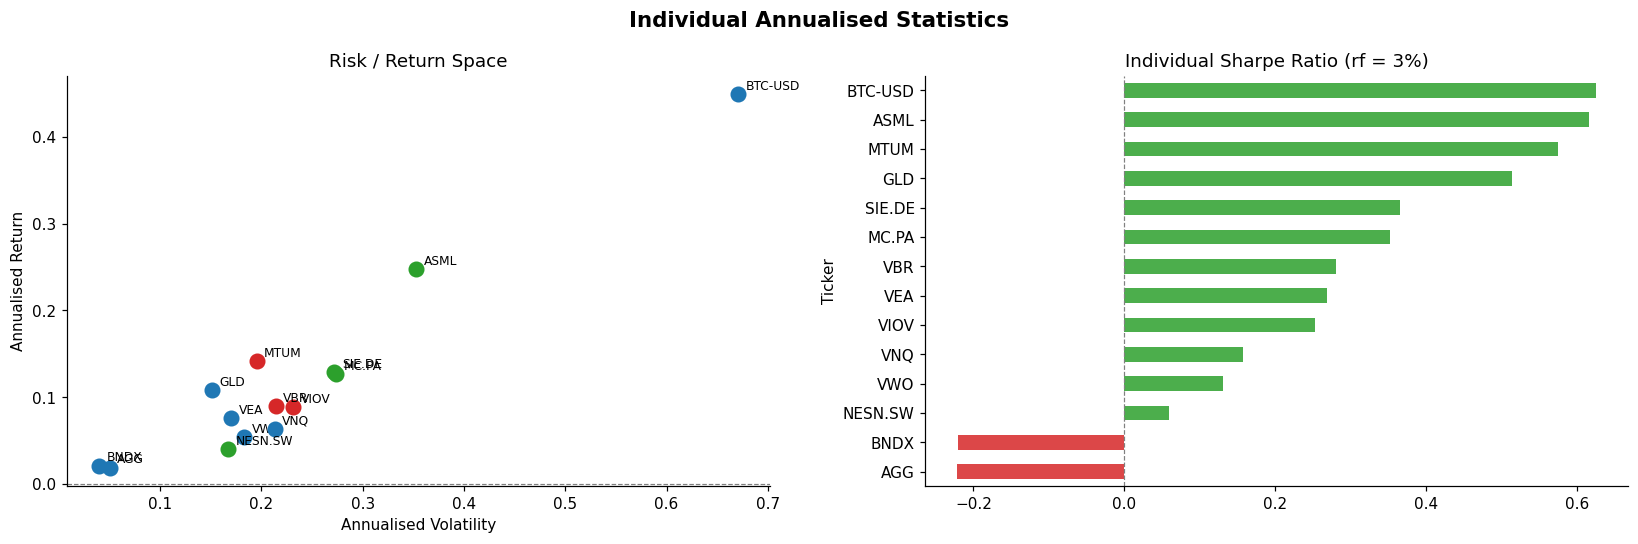

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Individual Annualised Statistics', fontsize=14, fontweight='bold')
ax1 = axes[0]
colors_group = (['#d62728']*3 + ['#1f77b4']*7 + ['#2ca02c']*4)
for t, c in zip(PORTFOLIO_TICKERS, colors_group):
    ax1.scatter(ann_vol[t], ann_ret[t], s=90, color=c, zorder=3)
    ax1.annotate(t, (ann_vol[t], ann_ret[t]), textcoords='offset points', xytext=(5,3), fontsize=8)
ax1.axhline(0, color='grey', lw=0.8, linestyle='--')
ax1.set_xlabel('Annualised Volatility'); ax1.set_ylabel('Annualised Return')
ax1.set_title('Risk / Return Space')
ax2 = axes[1]
sharpe_sorted = stats['Individual Sharpe'].sort_values()
bar_colors = ['#d62728' if v < 0 else '#2ca02c' for v in sharpe_sorted]
sharpe_sorted.plot(kind='barh', ax=ax2, color=bar_colors, alpha=0.85)
ax2.axvline(0, color='grey', lw=0.8, linestyle='--')
ax2.set_title('Individual Sharpe Ratio (rf = 3%)')
plt.tight_layout(); plt.show()

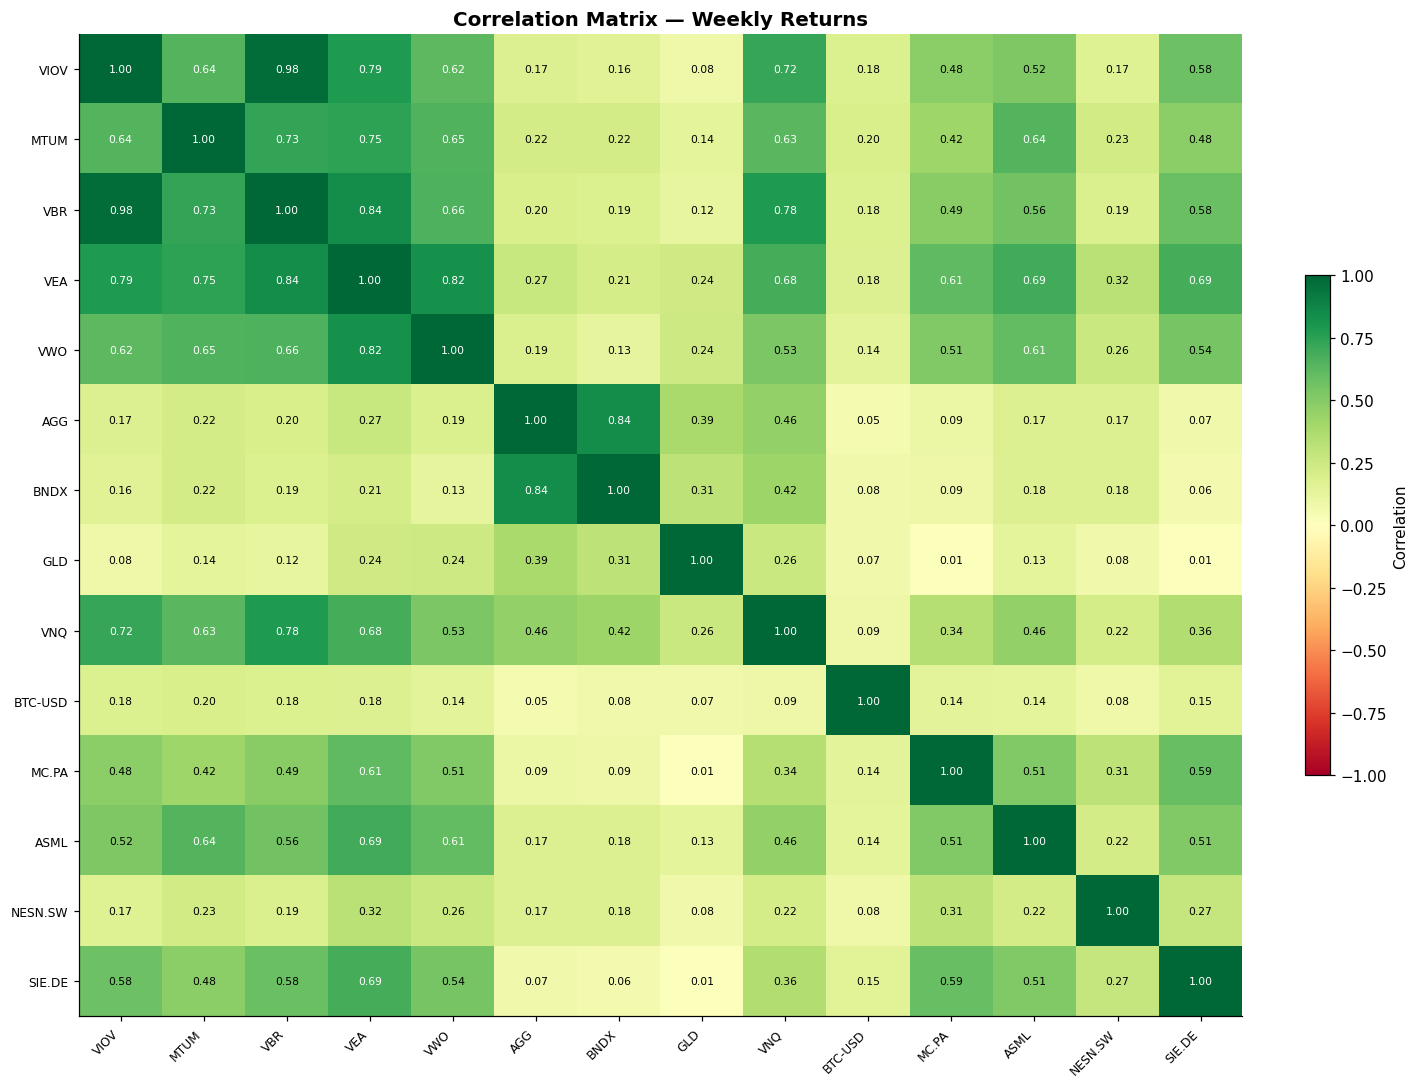

Average correlation (best diversifiers first):
Ticker
BTC-USD    0.193
GLD        0.220
NESN.SW    0.265
BNDX       0.290
AGG        0.307
MC.PA      0.399
SIE.DE     0.421
ASML       0.453
VWO        0.493
MTUM       0.497
VNQ        0.497
VIOV       0.507
VBR        0.535
VEA        0.577
dtype: float64


In [7]:
# Correlation matrix — weekly returns
corr = weekly_returns.corr()
fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(PORTFOLIO_TICKERS)))
ax.set_yticks(range(len(PORTFOLIO_TICKERS)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr.index, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.values[i, j]
        col = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=col)
plt.colorbar(im, ax=ax, fraction=0.02, label='Correlation')
ax.set_title('Correlation Matrix — Weekly Returns', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

corr_mean = corr.mean().sort_values()
print('Average correlation (best diversifiers first):')
print(corr_mean.round(3))

## 3. Instrument Selection

Each instrument must have at least **10 years of history** to support the backtest.

Note: individual stocks (MC.PA, ASML, NESN.SW, SIE.DE) are included in the factor analysis but **excluded from P3** for the following reasons: (1) excessive concentration incompatible with the ETF-only profile and TER constraint, (2) lower liquidity and tracking, (3) European geographic exposures are efficiently captured via VEA.


In [8]:
history = pd.DataFrame({
    'First Date': prices.apply(lambda x: x.first_valid_index()),
    'Last Date':  prices.apply(lambda x: x.last_valid_index()),
})
history['Years'] = ((history['Last Date'] - history['First Date']).dt.days / 365.25).round(1)
history['✓ 10 yrs'] = history['Years'] >= 10
history = history.sort_values('Years', ascending=False)
print('=== Historical Data Availability by Asset ===\n')
print(history.to_string())
print(f"\n{history['✓ 10 yrs'].sum()}/{len(history)} assets meet the 10-year criterion.")

=== Historical Data Availability by Asset ===

        First Date  Last Date  Years  ✓ 10 yrs
Ticker                                        
VIOV    2014-09-21 2026-05-24   11.7      True
MTUM    2014-09-21 2026-05-24   11.7      True
VBR     2014-09-21 2026-05-24   11.7      True
VEA     2014-09-21 2026-05-24   11.7      True
VWO     2014-09-21 2026-05-24   11.7      True
AGG     2014-09-21 2026-05-24   11.7      True
BNDX    2014-09-21 2026-05-24   11.7      True
GLD     2014-09-21 2026-05-24   11.7      True
VNQ     2014-09-21 2026-05-24   11.7      True
BTC-USD 2014-09-21 2026-05-24   11.7      True
MC.PA   2014-09-21 2026-05-24   11.7      True
ASML    2014-09-21 2026-05-24   11.7      True
NESN.SW 2014-09-21 2026-05-24   11.7      True
SIE.DE  2014-09-21 2026-05-24   11.7      True

14/14 assets meet the 10-year criterion.


## 4. Portfolio Construction

### 4.1 Fixed-Mix — US Equity Sub-Portfolio (P2) & Initial Global Allocation


In [9]:
US_SUB = ['VIOV', 'MTUM', 'VBR']
w_us_fixed = pd.Series({t: 1/3 for t in US_SUB}, name='US Equity Fixed-Mix (P2)')

# Allocation globale diversifiée (base pour P3)
GLOBAL_FIXED = pd.Series({
    'VIOV': 0.12, 'MTUM': 0.11, 'VBR':  0.10,
    'VEA':  0.15, 'VWO':  0.08,
    'AGG':  0.15, 'BNDX': 0.12,
    'GLD':  0.08, 'VNQ':  0.04,
    'BIL':  0.05,
}, name='Global Fixed-Mix (P3 base)')

print('P2 — US Equity Sub-Portfolio:'); print(w_us_fixed.to_string())
print(f'Total: {w_us_fixed.sum():.0%}\n')
print('P3 base — Global Portfolio:'); print(GLOBAL_FIXED.to_string())
print(f'Total: {GLOBAL_FIXED.sum():.0%}')

P2 — US Equity Sub-Portfolio:
VIOV    0.333333
MTUM    0.333333
VBR     0.333333
Total: 100%

P3 base — Global Portfolio:
VIOV    0.12
MTUM    0.11
VBR     0.10
VEA     0.15
VWO     0.08
AGG     0.15
BNDX    0.12
GLD     0.08
VNQ     0.04
BIL     0.05
Total: 100%


### 4.2 Weight Optimisation — FF3 & CAPM (Max Sharpe)


In [10]:
try:
    import pandas_datareader.data as web
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pandas-datareader', '-q'])
    import pandas_datareader.data as web

In [11]:
# ── FF3 download ──────────────────────────────────────────────────────
ff3_raw = web.DataReader('F-F_Research_Data_Factors_daily', 'famafrench', start=START)[0]
if not isinstance(ff3_raw.index, pd.DatetimeIndex):
    ff3_raw.index = pd.to_datetime(ff3_raw.index.astype(str), format='%Y%m%d')
ff3_daily = ff3_raw / 100

# Weekly compounding (∏(1+r)-1 over each week)
ff3_weekly = (1 + ff3_daily).resample('W').prod() - 1

mkt_weekly = np.log(weekly_prices['VT'] / weekly_prices['VT'].shift(1)).dropna()

common_idx = (weekly_returns.index
              .intersection(ff3_weekly.index)
              .intersection(mkt_weekly.index))

R       = weekly_returns.loc[common_idx, PORTFOLIO_TICKERS]
F       = ff3_weekly.loc[common_idx]
rf_w    = F['RF']
factors = F[['Mkt-RF', 'SMB', 'HML']]

# Compound annualisation (52 weeks)
rf_annual     = (1 + rf_w).prod() ** (52 / len(rf_w)) - 1
factor_premia = (1 + factors).prod() ** (52 / len(factors)) - 1

# ── FF3 regression ──────────────────────────────────────────────────────────
betas_ff3 = {}; alphas_ff3 = {}; r2_ff3 = {}
for t in PORTFOLIO_TICKERS:
    excess = (R[t] - rf_w).values
    X = np.column_stack([np.ones(len(factors)), factors.values])
    coeffs, _, _, _ = np.linalg.lstsq(X, excess, rcond=None)
    y_pred = X @ coeffs
    ss_res = np.sum((excess - y_pred)**2)
    ss_tot = np.sum((excess - excess.mean())**2)
    # Annualised alpha: compounding over 52 weeks (fix vs *252)
    alphas_ff3[t] = (1 + coeffs[0])**52 - 1
    betas_ff3[t]  = dict(zip(['Mkt-RF', 'SMB', 'HML'], coeffs[1:]))
    r2_ff3[t]     = 1 - ss_res / ss_tot

betas_df = pd.DataFrame(betas_ff3).T

mu_ff3 = pd.Series({
    t: rf_annual
       + betas_ff3[t]['Mkt-RF'] * factor_premia['Mkt-RF']
       + betas_ff3[t]['SMB']    * factor_premia['SMB']
       + betas_ff3[t]['HML']    * factor_premia['HML']
    for t in PORTFOLIO_TICKERS
}, name='E[r] FF3')

print('Annualised FF3 factor premia (compounded):')
print(factor_premia.round(4))
print(f'\nAnnualised rf: {rf_annual:.4f}\n')
print('FF3 expected returns:')
print(mu_ff3.sort_values(ascending=False).round(4))

Annualised FF3 factor premia (compounded):
Mkt-RF    0.0980
SMB      -0.0385
HML      -0.0070
dtype: float64

Annualised rf: 0.0281

FF3 expected returns:
ASML       0.1701
MTUM       0.1415
VNQ        0.1162
VBR        0.1063
VEA        0.1005
VIOV       0.0896
MC.PA      0.0882
VWO        0.0881
SIE.DE     0.0859
BTC-USD    0.0658
NESN.SW    0.0525
GLD        0.0411
AGG        0.0341
BNDX       0.0339
Name: E[r] FF3, dtype: float64


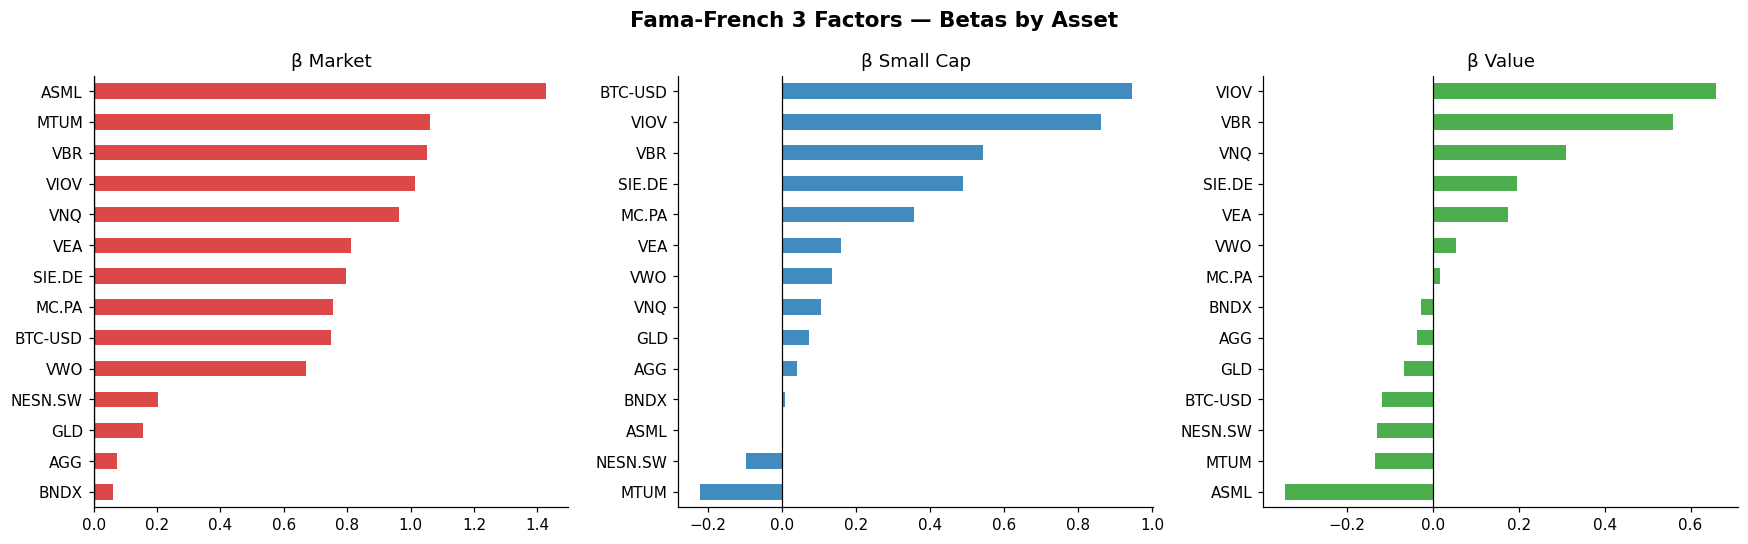

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Fama-French 3 Factors — Betas by Asset', fontsize=14, fontweight='bold')
factor_meta = [('Mkt-RF','#d62728','β Market'),('SMB','#1f77b4','β Small Cap'),('HML','#2ca02c','β Value')]
for ax, (factor, color, label) in zip(axes, factor_meta):
    betas_df[factor].sort_values().plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.axvline(0, color='black', lw=0.8); ax.set_title(label)
plt.tight_layout(); plt.show()

In [13]:
mkt_aligned = mkt_weekly.loc[common_idx]
betas_capm = {}; alphas_capm = {}; r2_capm = {}
for t in PORTFOLIO_TICKERS:
    excess_i   = R[t] - rf_w
    excess_mkt = mkt_aligned - rf_w
    slope, intercept, r_val, _, _ = sp_stats.linregress(excess_mkt, excess_i)
    betas_capm[t]  = slope
    # Annualised alpha: compounding (fix vs *52)
    alphas_capm[t] = (1 + intercept)**52 - 1
    r2_capm[t]     = r_val**2

mkt_premium = (mkt_aligned - rf_w).mean() * 52
mu_capm = pd.Series({
    t: rf_annual + betas_capm[t] * mkt_premium for t in PORTFOLIO_TICKERS
}, name='E[r] CAPM')

print(f'Market premium (VT): {mkt_premium:.4f}')
print(pd.concat([pd.Series(betas_capm, name='Beta'), pd.Series(r2_capm, name='R2')], axis=1).round(3))

Market premium (VT): 0.0757
          Beta     R2
VIOV     1.231  0.711
MTUM     1.067  0.759
VBR      1.223  0.807
VEA      0.974  0.894
VWO      0.826  0.677
AGG      0.099  0.096
BNDX     0.070  0.082
GLD      0.230  0.069
VNQ      1.063  0.624
BTC-USD  0.942  0.078
MC.PA    0.945  0.337
ASML     1.571  0.542
NESN.SW  0.227  0.055
SIE.DE   1.027  0.398


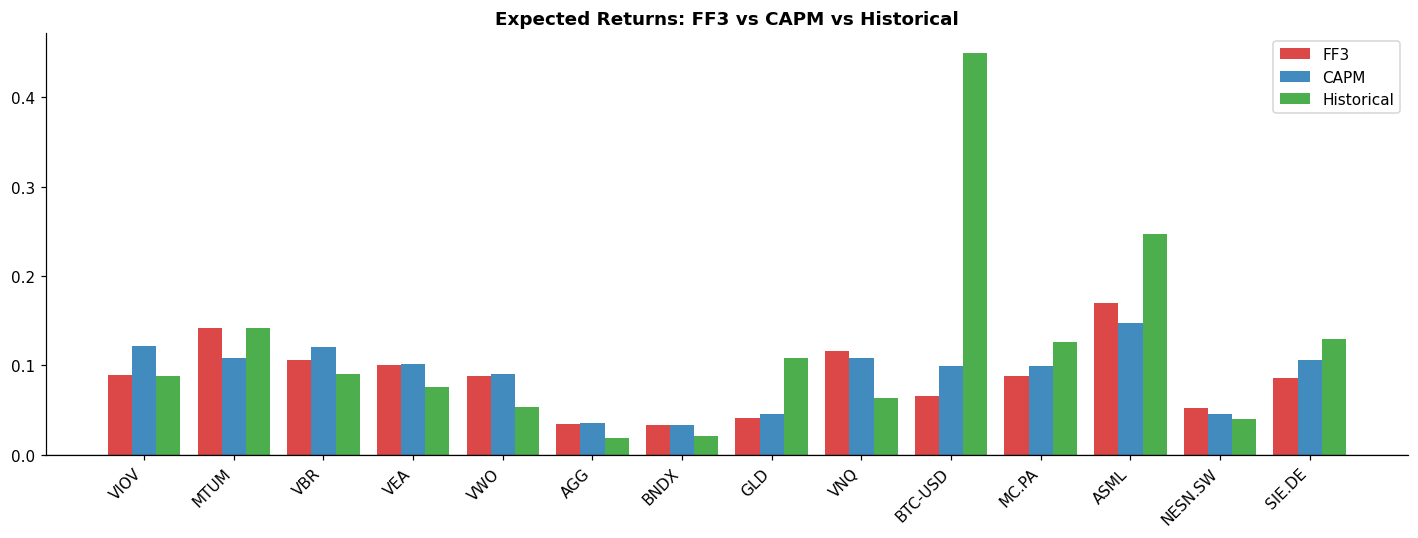

In [14]:
mu_compare = pd.DataFrame({'FF3': mu_ff3, 'CAPM': mu_capm, 'Historical': ann_ret.loc[PORTFOLIO_TICKERS]})
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(PORTFOLIO_TICKERS)); width = 0.27
ax.bar(x-width, mu_compare['FF3'],       width, label='FF3',       color='#d62728', alpha=0.85)
ax.bar(x,       mu_compare['CAPM'],      width, label='CAPM',      color='#1f77b4', alpha=0.85)
ax.bar(x+width, mu_compare['Historical'],width, label='Historical',color='#2ca02c', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(PORTFOLIO_TICKERS, rotation=45, ha='right')
ax.set_title('Expected Returns: FF3 vs CAPM vs Historical', fontweight='bold')
ax.axhline(0, color='black', lw=0.8); ax.legend()
plt.tight_layout(); plt.show()

In [15]:
cov = R.cov() * 52
n   = len(PORTFOLIO_TICKERS)

def portfolio_metrics(w, mu, cov, rf):
    ret = w @ mu; vol = np.sqrt(w @ cov @ w); sr = (ret - rf) / vol
    return ret, vol, sr

def neg_sharpe(w, mu, cov, rf):
    return -portfolio_metrics(w, mu, cov, rf)[2]

constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
bounds = [(0.0, 0.40)] * n
w0 = np.ones(n) / n
opts = {'ftol': 1e-12, 'maxiter': 2000}

res_ff3  = minimize(neg_sharpe, w0, args=(mu_ff3.values,  cov.values, rf_annual),
                    method='SLSQP', bounds=bounds, constraints=constraints, options=opts)
res_capm = minimize(neg_sharpe, w0, args=(mu_capm.values, cov.values, rf_annual),
                    method='SLSQP', bounds=bounds, constraints=constraints, options=opts)

w_ff3  = pd.Series(res_ff3.x,  index=PORTFOLIO_TICKERS)
w_capm = pd.Series(res_capm.x, index=PORTFOLIO_TICKERS)
w_ew   = pd.Series(np.ones(n)/n, index=PORTFOLIO_TICKERS)

def fmt_m(w, mu, label):
    r, v, s = portfolio_metrics(w.values, mu.values, cov.values, rf_annual)
    return pd.Series({'Expected Return': r, 'Volatility': v, 'Sharpe': s}, name=label)

summary = pd.concat([fmt_m(w_ff3, mu_ff3, 'FF3'), fmt_m(w_capm, mu_capm, 'CAPM'), fmt_m(w_ew, mu_ff3, 'EW')], axis=1)
print('=== Optimal Portfolios (ex-ante) ===\n'); print(summary.round(4))

=== Optimal Portfolios (ex-ante) ===

                    FF3    CAPM      EW
Expected Return  0.0908  0.1069  0.0867
Volatility       0.1236  0.1898  0.1600
Sharpe           0.5074  0.4151  0.3663


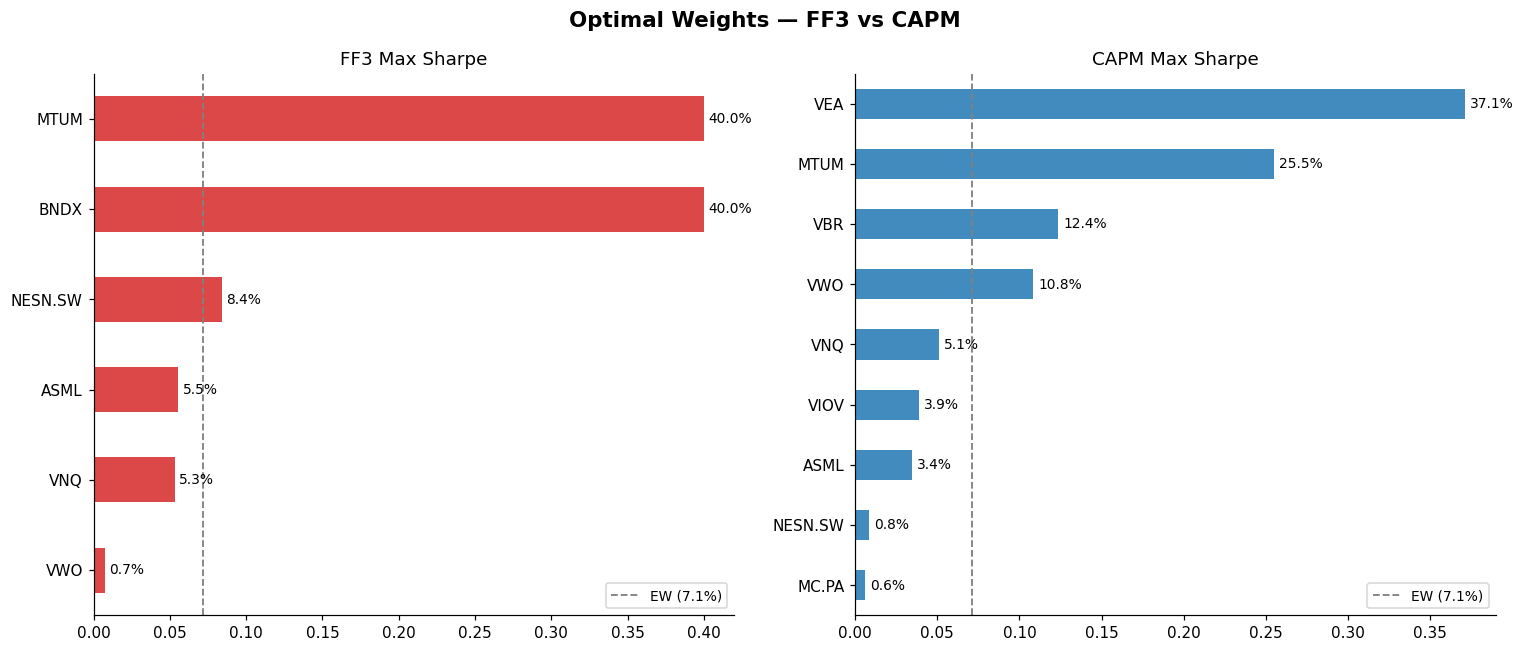

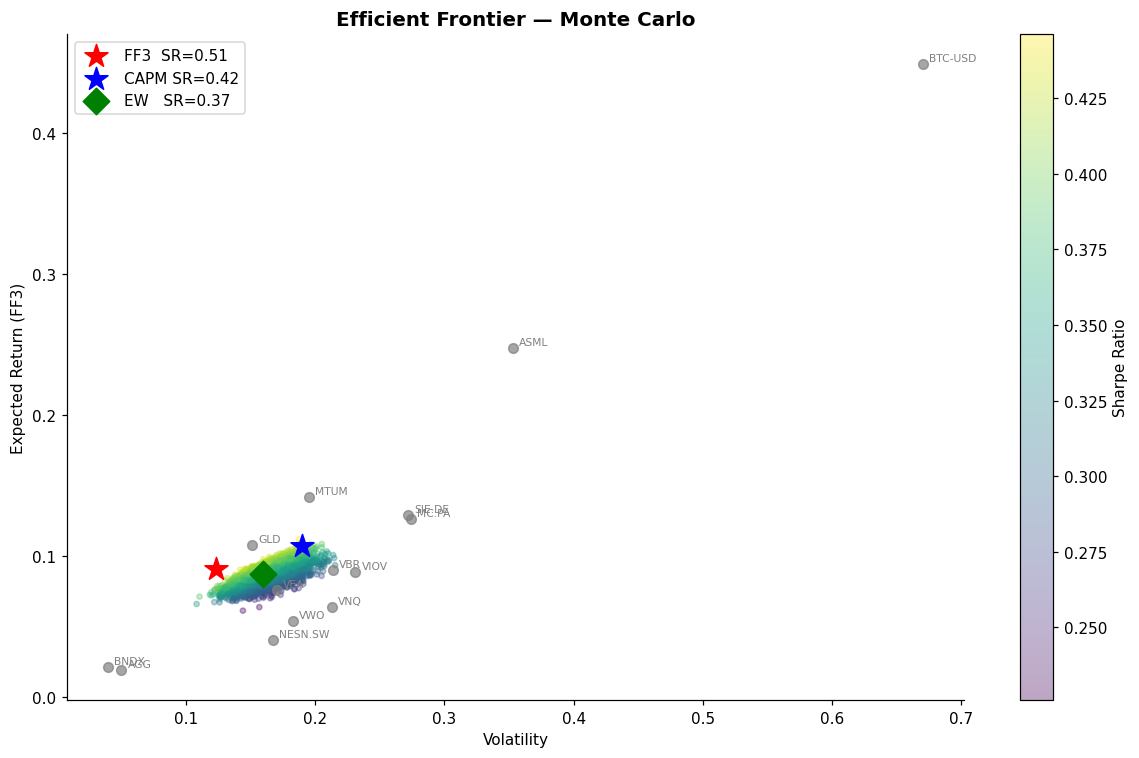

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Optimal Weights — FF3 vs CAPM', fontsize=14, fontweight='bold')
for ax, (weights, model, color) in zip(axes, [
    (w_ff3, 'FF3 Max Sharpe', '#d62728'), (w_capm, 'CAPM Max Sharpe', '#1f77b4')]):
    w_plot = weights[weights > 0.005].sort_values(ascending=True)
    w_plot.plot(kind='barh', ax=ax, color=color, alpha=0.85)
    ax.axvline(1/n, color='grey', linestyle='--', lw=1.2, label=f'EW ({1/n:.1%})')
    for i, val in enumerate(w_plot): ax.text(val+0.003, i, f'{val:.1%}', va='center', fontsize=9)
    ax.set_title(model); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# Monte Carlo frontière efficiente
N_SIM = 6000
rng = np.random.default_rng(42)
sim_ret = np.zeros(N_SIM); sim_vol = np.zeros(N_SIM); sim_sr = np.zeros(N_SIM)
for i in range(N_SIM):
    w = rng.random(n); w /= w.sum()
    r, v, s = portfolio_metrics(w, mu_ff3.values, cov.values, rf_annual)
    sim_ret[i] = r; sim_vol[i] = v; sim_sr[i] = s

r_ff3, v_ff3, s_ff3   = portfolio_metrics(w_ff3.values,  mu_ff3.values, cov.values, rf_annual)
r_capm, v_capm, s_capm = portfolio_metrics(w_capm.values, mu_capm.values, cov.values, rf_annual)
r_ew,   v_ew,   s_ew   = portfolio_metrics(w_ew.values,   mu_ff3.values, cov.values, rf_annual)

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(sim_vol, sim_ret, c=sim_sr, cmap='viridis', alpha=0.35, s=12)
plt.colorbar(sc, ax=ax, label='Sharpe Ratio')
for t in PORTFOLIO_TICKERS:
    ax.scatter(ann_vol[t], ann_ret[t], s=40, color='grey', zorder=4, alpha=0.7)
    ax.annotate(t, (ann_vol[t], ann_ret[t]), fontsize=7, color='grey',
                textcoords='offset points', xytext=(4, 2))
ax.scatter(v_ff3,  r_ff3,  s=250, color='red',   zorder=6, marker='*', label=f'FF3  SR={s_ff3:.2f}')
ax.scatter(v_capm, r_capm, s=250, color='blue',  zorder=6, marker='*', label=f'CAPM SR={s_capm:.2f}')
ax.scatter(v_ew,   r_ew,   s=150, color='green', zorder=6, marker='D', label=f'EW   SR={s_ew:.2f}')
ax.set_xlabel('Volatility'); ax.set_ylabel('Expected Return (FF3)')
ax.set_title('Efficient Frontier — Monte Carlo', fontweight='bold', fontsize=13)
ax.legend(fontsize=10); plt.tight_layout(); plt.show()

## 5. Benchmark Construction (P1)

Benchmark: **60% VT** (global equities) **+ 40% AGG** (US bonds).


=== P1 — 60/40 Benchmark (VT 60% + AGG 40%) ===
Annualised Return   : 7.02%
Annualised Volatility: 11.72%
Sharpe Ratio        : 0.359
Max Drawdown        : -22.41%


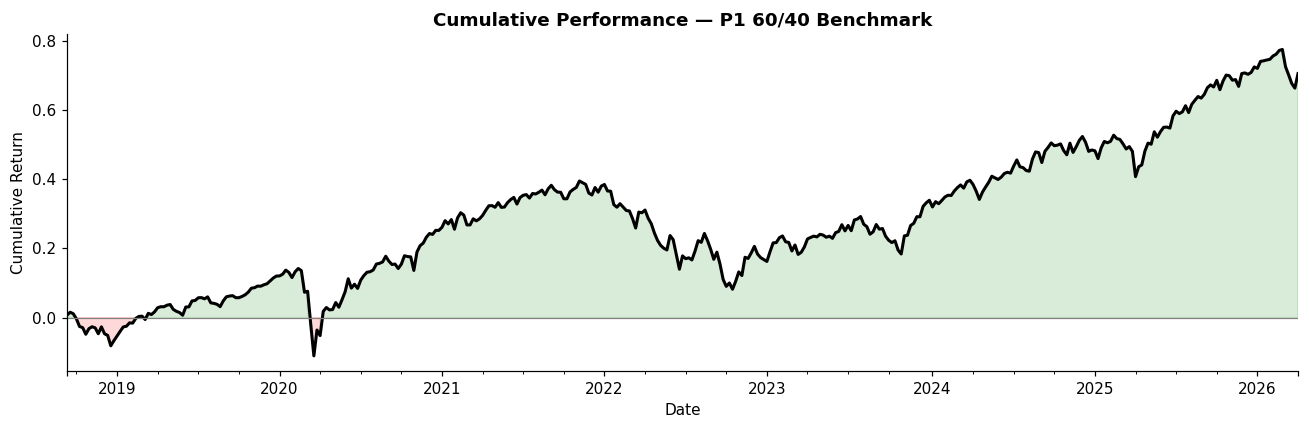

In [17]:
bench_w = pd.Series({'VT': 0.60, 'AGG': 0.40})
bench_prices_raw    = raw[['VT', 'AGG']].ffill().dropna()
bench_prices_weekly = bench_prices_raw.resample('W').last()
bench_returns       = np.log(bench_prices_weekly / bench_prices_weekly.shift(1)).dropna()
bench_6040_raw      = (bench_returns * bench_w).sum(axis=1)
bench_6040          = bench_6040_raw.reindex(common_idx).dropna()
bench_6040.name     = '60/40 Benchmark (P1)'

ret_b = bench_6040.mean() * 52
vol_b = bench_6040.std()  * np.sqrt(52)
sr_b  = (ret_b - rf_annual) / vol_b
dd_b  = (np.exp(bench_6040.cumsum()) / np.exp(bench_6040.cumsum()).cummax() - 1).min()

print('=== P1 — 60/40 Benchmark (VT 60% + AGG 40%) ===')
print(f'Annualised Return   : {ret_b:.2%}')
print(f'Annualised Volatility: {vol_b:.2%}')
print(f'Sharpe Ratio        : {sr_b:.3f}')
print(f'Max Drawdown        : {dd_b:.2%}')

fig, ax = plt.subplots(figsize=(12, 4))
cum_b = np.exp(bench_6040.cumsum()) - 1
cum_b.plot(ax=ax, color='black', lw=2)
ax.fill_between(cum_b.index, 0, cum_b, where=cum_b >= 0, alpha=0.15, color='green')
ax.fill_between(cum_b.index, 0, cum_b, where=cum_b  < 0, alpha=0.15, color='red')
ax.set_title('Cumulative Performance — P1 60/40 Benchmark', fontweight='bold')
ax.set_ylabel('Cumulative Return'); ax.axhline(0, color='grey', lw=0.8)
plt.tight_layout(); plt.show()

## 6. Factor Regression — FF6 (FF5 + Momentum)

Regression on the **US Equity sub-portfolio (P2)** (VIOV, MTUM, VBR):

$$r_i - r_f = \\alpha + \\beta_{\\text{mkt}}\\cdot MKT + \\beta_{\\text{smb}}\\cdot SMB + \\beta_{\\text{hml}}\\cdot HML + \\beta_{\\text{rmw}}\\cdot RMW + \\beta_{\\text{cma}}\\cdot CMA + \\beta_{\\text{mom}}\\cdot MOM + \\varepsilon$$


In [18]:
# ── FF5 + Momentum download ───────────────────────────────────────────
ff5_raw = web.DataReader('F-F_Research_Data_5_Factors_2x3_daily', 'famafrench', start=START)[0]
if not isinstance(ff5_raw.index, pd.DatetimeIndex):
    ff5_raw.index = pd.to_datetime(ff5_raw.index.astype(str), format='%Y%m%d')
ff5 = ff5_raw / 100

mom_raw = web.DataReader('F-F_Momentum_Factor_daily', 'famafrench', start=START)[0]
if not isinstance(mom_raw.index, pd.DatetimeIndex):
    mom_raw.index = pd.to_datetime(mom_raw.index.astype(str), format='%Y%m%d')
mom = mom_raw / 100

FACTORS_FF6   = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'Mom']
ff6_all_daily = ff5[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']].join(mom[['Mom']], how='inner')

# ── FIX: weekly compounding (not daily sum)
ff6_all = (1 + ff6_all_daily).resample('W').prod() - 1

# Index alignment
us_common = R[US_SUB].index.intersection(ff6_all.index).intersection(F.index)
R_us      = R.loc[us_common, US_SUB]
ff6_al    = ff6_all.loc[us_common, FACTORS_FF6]
rf_us     = F.loc[us_common, 'RF']

# ── OLS regression with REAL t-stats ─────────────────────────────────────
from scipy.stats import t as t_dist

betas_ff6  = {}
alphas_ff6 = {}
r2_ff6     = {}
tstats_ff6 = {}
pvals_ff6  = {}
se_ff6     = {}

for ticker in US_SUB:
    excess = (R_us[ticker] - rf_us).values
    X      = np.column_stack([np.ones(len(ff6_al)), ff6_al.values])
    T, K   = X.shape  # observations, number of regressors

    # OLS : coefficients
    XtX_inv = np.linalg.inv(X.T @ X)
    coeffs  = XtX_inv @ X.T @ excess
    y_pred  = X @ coeffs
    resid   = excess - y_pred
    ss_res  = resid @ resid
    ss_tot  = np.sum((excess - excess.mean())**2)

    # Coefficient variance-covariance matrix (standard OLS)
    sigma2 = ss_res / (T - K)
    cov_b  = sigma2 * XtX_inv
    se     = np.sqrt(np.diag(cov_b))   # standard errors

    # two-sided t-stats and p-values
    t_vals = coeffs / se
    p_vals = 2 * t_dist.sf(np.abs(t_vals), df=T - K)

    # Annualised alpha: compounding over 52 weeks (FIX)
    alphas_ff6[ticker]  = (1 + coeffs[0])**52 - 1
    betas_ff6[ticker]   = dict(zip(FACTORS_FF6, coeffs[1:]))
    r2_ff6[ticker]      = 1 - ss_res / ss_tot
    tstats_ff6[ticker]  = dict(zip(['alpha'] + FACTORS_FF6, t_vals))
    pvals_ff6[ticker]   = dict(zip(['alpha'] + FACTORS_FF6, p_vals))
    se_ff6[ticker]      = dict(zip(['alpha'] + FACTORS_FF6, se))

betas_ff6_df  = pd.DataFrame(betas_ff6).T
tstats_ff6_df = pd.DataFrame({t: {f: tstats_ff6[t][f] for f in FACTORS_FF6} for t in US_SUB}).T
pvals_ff6_df  = pd.DataFrame({t: {f: pvals_ff6[t][f]  for f in FACTORS_FF6} for t in US_SUB}).T

print('=== FF6 — US Equity Sub-Portfolio (P2) ===\n')
print('Betas:'); print(betas_ff6_df.round(4))
print('\nAnnualised alphas:', {t: round(v, 4) for t, v in alphas_ff6.items()})
print('R²:', {t: round(v, 4) for t, v in r2_ff6.items()})

=== FF6 — US Equity Sub-Portfolio (P2) ===

Betas:
      Mkt-RF     SMB     HML     RMW     CMA     Mom
VIOV  1.0136  0.9235  0.3592  0.1941  0.1133 -0.0571
MTUM  1.0994 -0.1272  0.0671 -0.1840 -0.0214  0.3956
VBR   1.0503  0.6093  0.4020  0.1083  0.0077  0.0134

Annualised alphas: {'VIOV': np.float64(-0.054), 'MTUM': np.float64(-0.0493), 'VBR': np.float64(-0.0508)}
R²: {'VIOV': np.float64(0.9767), 'MTUM': np.float64(0.9325), 'VBR': np.float64(0.9723)}


In [19]:
print('\n' + '='*80)
print('FF6 FACTOR REGRESSION — SUMMARY WITH REAL T-STATS')
print('='*80)
print(f'Portfolio: US Equity Sub-Portfolio (VIOV, MTUM, VBR) — equal-weight')
print(f'Data     : weekly (asynchronous trading adjustment) | n={len(us_common)} obs')
print(f'\nEqual-weighted portfolio average betas:')
avg_betas  = betas_ff6_df.mean()
avg_tstats = tstats_ff6_df.mean()
avg_pvals  = pvals_ff6_df.mean()
print(f'  {"Factor":<10} | {"Avg Beta":>9} | {"Avg t-stat":>11} | {"Avg p-val":>10} | Sig')
print('  ' + '-'*58)
for f in FACTORS_FF6:
    b = avg_betas[f]; t_s = avg_tstats[f]; p = avg_pvals[f]
    sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
    print(f'  {f:<10} | {b:>9.4f} | {t_s:>11.3f} | {p:>10.4f} | {sig}')
print('  ' + '-'*58)
print('  *** p<0.01   ** p<0.05   * p<0.10')

print('\n--- Detail by asset ---')
for ticker in US_SUB:
    print(f'\n  {ticker}  (R²={r2_ff6[ticker]:.3f}  |  α annualised={alphas_ff6[ticker]:.2%})')
    print(f'  {"Factor":<10} | {"Beta":>8} | {"SE":>8} | {"t-stat":>8} | {"p-val":>8} | Sig')
    print('  ' + '-'*58)
    for f in FACTORS_FF6:
        b  = betas_ff6[ticker][f]
        se = se_ff6[ticker][f]
        t_s = tstats_ff6[ticker][f]
        p   = pvals_ff6[ticker][f]
        sig = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
        print(f'  {f:<10} | {b:>8.4f} | {se:>8.4f} | {t_s:>8.3f} | {p:>8.4f} | {sig}')


FF6 FACTOR REGRESSION — SUMMARY WITH REAL T-STATS
Portfolio: US Equity Sub-Portfolio (VIOV, MTUM, VBR) — equal-weight
Data     : weekly (asynchronous trading adjustment) | n=395 obs

Equal-weighted portfolio average betas:
  Factor     |  Avg Beta |  Avg t-stat |  Avg p-val | Sig
  ----------------------------------------------------------
  Mkt-RF     |    1.0544 |      82.971 |     0.0000 | ***
  SMB        |    0.4685 |      21.587 |     0.0000 | ***
  HML        |    0.2761 |      14.409 |     0.0039 | ***
  RMW        |    0.0395 |       2.209 |     0.0000 | ***
  CMA        |    0.0332 |       1.167 |     0.4741 | 
  Mom        |    0.1173 |       6.179 |     0.0988 | *
  ----------------------------------------------------------
  *** p<0.01   ** p<0.05   * p<0.10

--- Detail by asset ---

  VIOV  (R²=0.977  |  α annualised=-5.40%)
  Factor     |     Beta |       SE |   t-stat |    p-val | Sig
  ----------------------------------------------------------
  Mkt-RF     |   1.0136 

In [20]:
# ── FF6 comparison: P2 vs SPY (broad market benchmark) ───────────────────

spy_raw = yf.download('SPY', start=START, end=END, auto_adjust=True, progress=False)

# Force SPY to clean Series
if isinstance(spy_raw.columns, pd.MultiIndex):
    spy_close = spy_raw[("Close", "SPY")]
else:
    spy_close = spy_raw["Close"]

spy_weekly = np.log(
    spy_close.resample("W").last() / spy_close.resample("W").last().shift(1)
).dropna()

spy_weekly = pd.Series(spy_weekly, name="SPY")

# Force RF to clean Series
rf_series = pd.Series(rf_us, name="RF")

# Robust alignment
spy_df = pd.concat(
    [
        spy_weekly,
        rf_series,
        ff6_al[FACTORS_FF6]
    ],
    axis=1
).dropna()

excess_spy = (spy_df["SPY"] - spy_df["RF"]).values.reshape(-1)

X_spy = np.column_stack([
    np.ones(len(spy_df)),
    spy_df[FACTORS_FF6].values
])

T_spy, K_spy = X_spy.shape

coeffs_spy = np.linalg.lstsq(X_spy, excess_spy, rcond=None)[0]
resid_spy = excess_spy - X_spy @ coeffs_spy

sigma2_spy = (resid_spy.T @ resid_spy) / (T_spy - K_spy)
se_spy = np.sqrt(np.diag(sigma2_spy * np.linalg.inv(X_spy.T @ X_spy)))
t_spy = coeffs_spy / se_spy

betas_spy = dict(zip(FACTORS_FF6, coeffs_spy[1:]))

r2_spy = 1 - (resid_spy.T @ resid_spy) / np.sum((excess_spy - excess_spy.mean())**2)

print('\n' + '='*80)
print('FF6 COMPARISON: P2 (VIOV/MTUM/VBR) vs SPY (US Market)')
print('='*80)
print(f'  {"Factor":<10} | {"P2 (avg beta)":>14} | {"SPY beta":>10} | Difference')
print('  ' + '-'*55)
for f in FACTORS_FF6:
    b_p2  = avg_betas[f]
    b_spy = betas_spy[f]
    print(f'  {f:<10} | {b_p2:>14.4f} | {b_spy:>10.4f} | {b_p2-b_spy:>+10.4f}')
r2_p2_avg = np.mean(list(r2_ff6.values()))
print(f'  {"R²":<10} | {r2_p2_avg:>14.3f} | {r2_spy:>10.3f} |')
print('\nInterpretation:')
print('  SMB > 0 for P2 vs ≈0 for SPY → Small Cap tilt confirmed')
print('  HML > 0 for P2 vs ≈0 for SPY → Value tilt confirmed')
print('  Mom > 0 for P2 vs ≈0 for SPY → Momentum tilt confirmed')


FF6 COMPARISON: P2 (VIOV/MTUM/VBR) vs SPY (US Market)
  Factor     |  P2 (avg beta) |   SPY beta | Difference
  -------------------------------------------------------
  Mkt-RF     |         1.0544 |     0.9930 |    +0.0614
  SMB        |         0.4685 |    -0.0927 |    +0.5612
  HML        |         0.2761 |     0.0143 |    +0.2618
  RMW        |         0.0395 |     0.0624 |    -0.0229
  CMA        |         0.0332 |     0.0463 |    -0.0131
  Mom        |         0.1173 |    -0.0104 |    +0.1277
  R²         |          0.960 |      0.996 |

Interpretation:
  SMB > 0 for P2 vs ≈0 for SPY → Small Cap tilt confirmed
  HML > 0 for P2 vs ≈0 for SPY → Value tilt confirmed
  Mom > 0 for P2 vs ≈0 for SPY → Momentum tilt confirmed


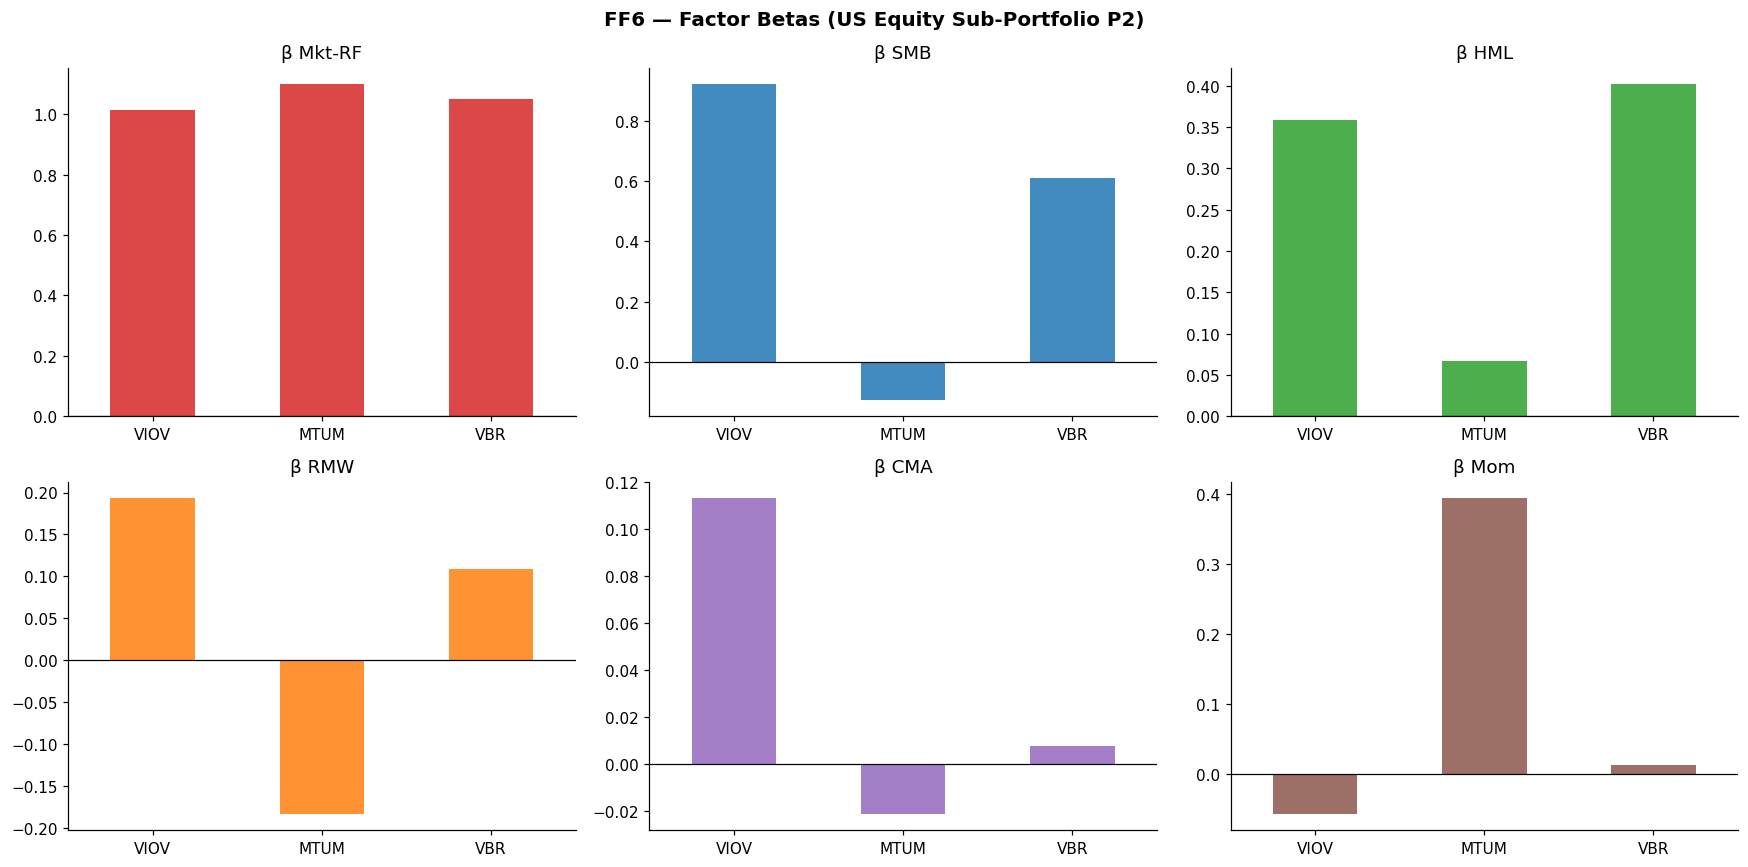

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('FF6 — Factor Betas (US Equity Sub-Portfolio P2)', fontsize=13, fontweight='bold')
f_colors = ['#d62728','#1f77b4','#2ca02c','#ff7f0e','#9467bd','#8c564b']
for ax, (factor, color) in zip(axes.flatten(), zip(FACTORS_FF6, f_colors)):
    betas_ff6_df[factor].plot(kind='bar', ax=ax, color=color, alpha=0.85)
    ax.axhline(0, color='black', lw=0.8); ax.set_title(f'β {factor}')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## 7. Backtest & Performance Analysis


In [22]:
# ── BIL download for P3 (cash proxy) ────────────────────────────────
bil_raw    = raw['BIL'].ffill().dropna()
bil_weekly = np.log(bil_raw.resample('W').last() / bil_raw.resample('W').last().shift(1)).dropna()
bil_weekly = bil_weekly.reindex(common_idx).fillna(0)   # ≈0 volatility, slight upward drift

# ── Portfolio returns (buy & hold) ──────────────────────────────────
port_ff3  = (R * w_ff3.values).sum(axis=1)
port_capm = (R * w_capm.values).sum(axis=1)
port_ew   = (R * w_ew.values).sum(axis=1)
port_vt   = np.log(weekly_prices['VT'] / weekly_prices['VT'].shift(1)).dropna().reindex(common_idx).dropna()

# ── Performance metrics ─────────────────────────────────────────────────
def perf_metrics(port_ret, rf_ann, label):
    ann_r = port_ret.mean() * 52
    ann_v = port_ret.std()  * np.sqrt(52)
    sr    = (ann_r - rf_ann) / ann_v
    cum   = np.exp(port_ret.cumsum())
    max_dd = (cum / cum.cummax() - 1).min()
    calmar = ann_r / abs(max_dd) if max_dd != 0 else np.nan
    down   = port_ret[port_ret < 0].std() * np.sqrt(52)
    sortino = (ann_r - rf_ann) / down if down > 0 else np.nan
    return pd.Series({
        'Annualised Return': ann_r, 'Volatility': ann_v,
        'Sharpe Ratio': sr, 'Sortino Ratio': sortino,
        'Max Drawdown': max_dd, 'Calmar Ratio': calmar
    }, name=label)

metrics = pd.concat([
    perf_metrics(port_ff3,  rf_annual, 'FF3 Max Sharpe'),
    perf_metrics(port_capm, rf_annual, 'CAPM Max Sharpe'),
    perf_metrics(port_ew,   rf_annual, 'Equal Weight'),
    perf_metrics(port_vt,   rf_annual, 'VT Benchmark'),
    perf_metrics(bench_6040,rf_annual, '60/40 Benchmark (P1)'),
], axis=1)
print('=== Ex-Post Metrics (Sharpe, Sortino, Calmar) ===\n')
print(metrics.round(4))

=== Ex-Post Metrics (Sharpe, Sortino, Calmar) ===

                   FF3 Max Sharpe  CAPM Max Sharpe  Equal Weight  \
Annualised Return          0.0707           0.0938        0.1068   
Volatility                 0.1236           0.1898        0.1600   
Sharpe Ratio               0.3445           0.3461        0.4922   
Sortino Ratio              0.4390           0.4203        0.6026   
Max Drawdown              -0.2399          -0.3401       -0.2928   
Calmar Ratio               0.2946           0.2758        0.3649   

                   VT Benchmark  60/40 Benchmark (P1)  
Annualised Return        0.1034                0.0702  
Volatility               0.1800                0.1172  
Sharpe Ratio             0.4185                0.3593  
Sortino Ratio            0.5130                0.4437  
Max Drawdown            -0.3256               -0.2241  
Calmar Ratio             0.3177                0.3133  


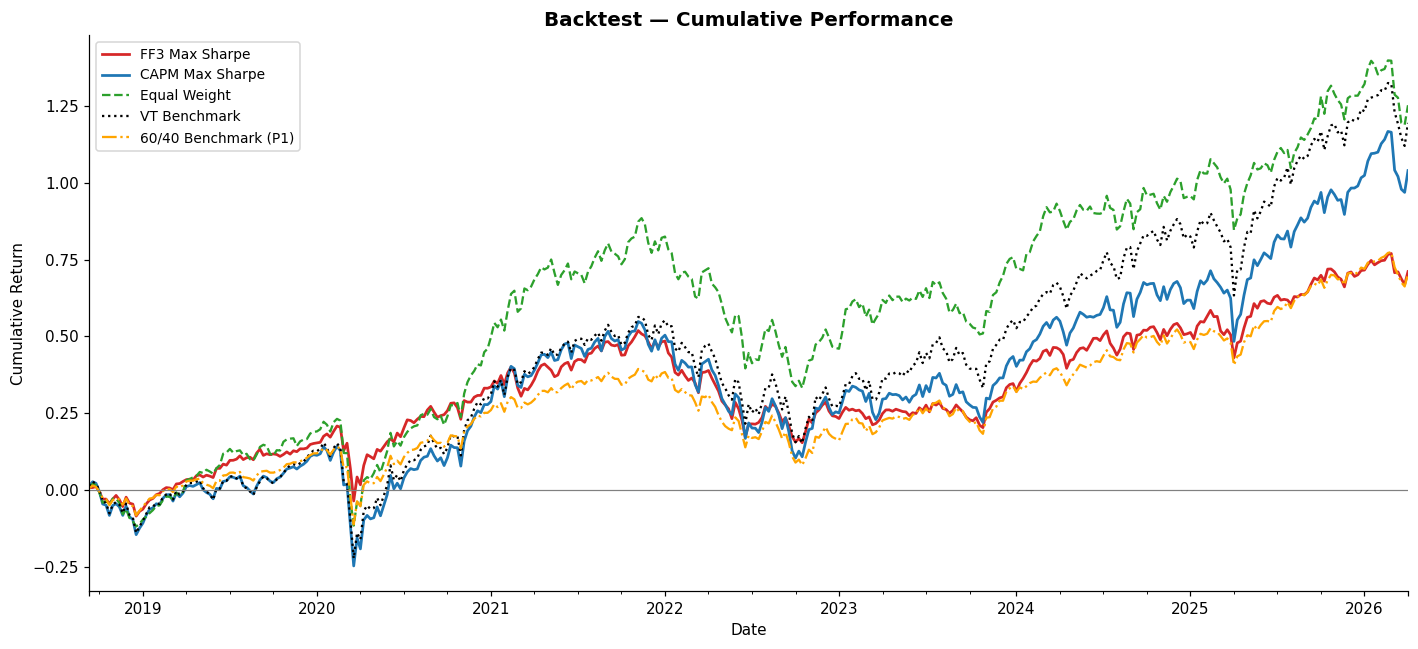

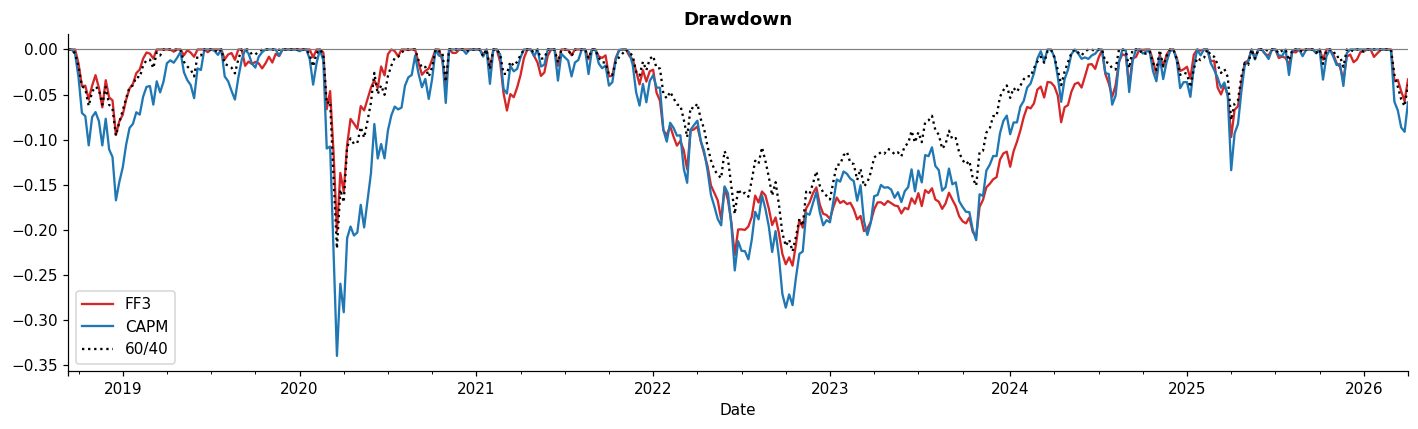

In [23]:
# Cumulative performance
fig, ax = plt.subplots(figsize=(13, 6))
(np.exp(port_ff3.cumsum())  - 1).plot(ax=ax, label='FF3 Max Sharpe',       color='#d62728', lw=1.8)
(np.exp(port_capm.cumsum()) - 1).plot(ax=ax, label='CAPM Max Sharpe',      color='#1f77b4', lw=1.8)
(np.exp(port_ew.cumsum())   - 1).plot(ax=ax, label='Equal Weight',          color='#2ca02c', lw=1.5, ls='--')
(np.exp(port_vt.cumsum())   - 1).plot(ax=ax, label='VT Benchmark',          color='black',   lw=1.5, ls=':')
(np.exp(bench_6040.cumsum())- 1).plot(ax=ax, label='60/40 Benchmark (P1)', color='orange',  lw=1.5, ls='-.')
ax.set_title('Backtest — Cumulative Performance', fontweight='bold', fontsize=13)
ax.set_ylabel('Cumulative Return'); ax.axhline(0, color='grey', lw=0.8); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# Drawdown
fig, ax = plt.subplots(figsize=(13, 4))
for port, label, color, ls in [
    (port_ff3,   'FF3',   '#d62728', '-'),
    (port_capm,  'CAPM',  '#1f77b4', '-'),
    (bench_6040, '60/40', 'black',   ':'),
]:
    cum = np.exp(port.cumsum())
    (cum / cum.cummax() - 1).plot(ax=ax, label=label, color=color, lw=1.5, ls=ls)
ax.set_title('Drawdown', fontweight='bold'); ax.legend(); ax.axhline(0, color='grey', lw=0.8)
plt.tight_layout(); plt.show()

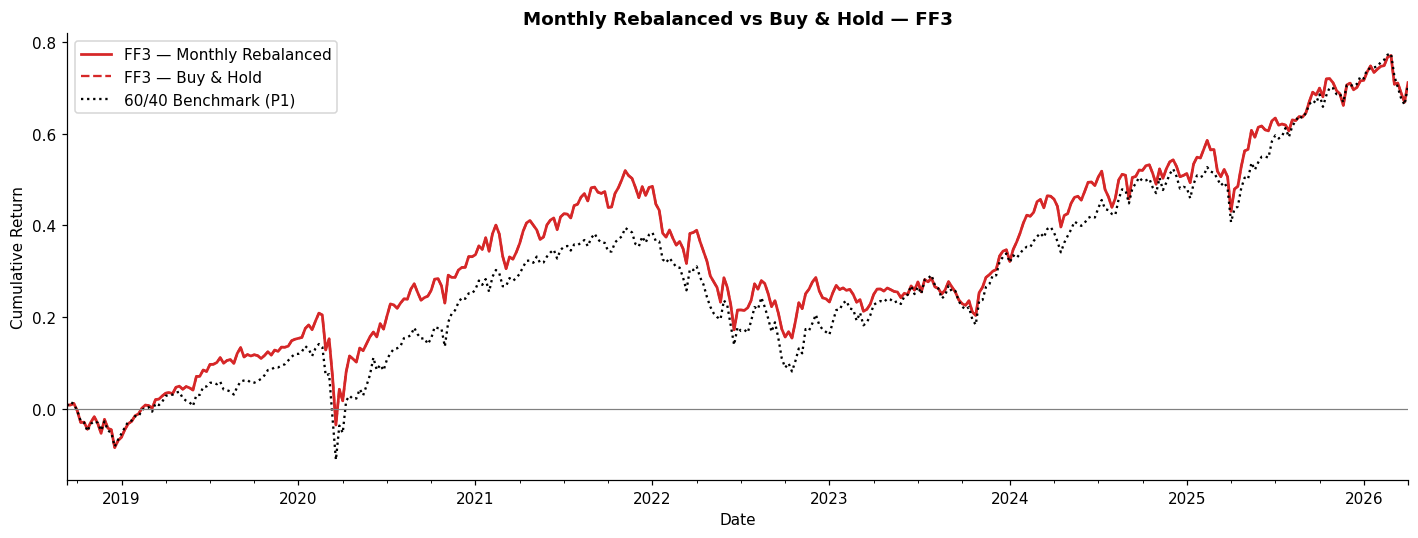

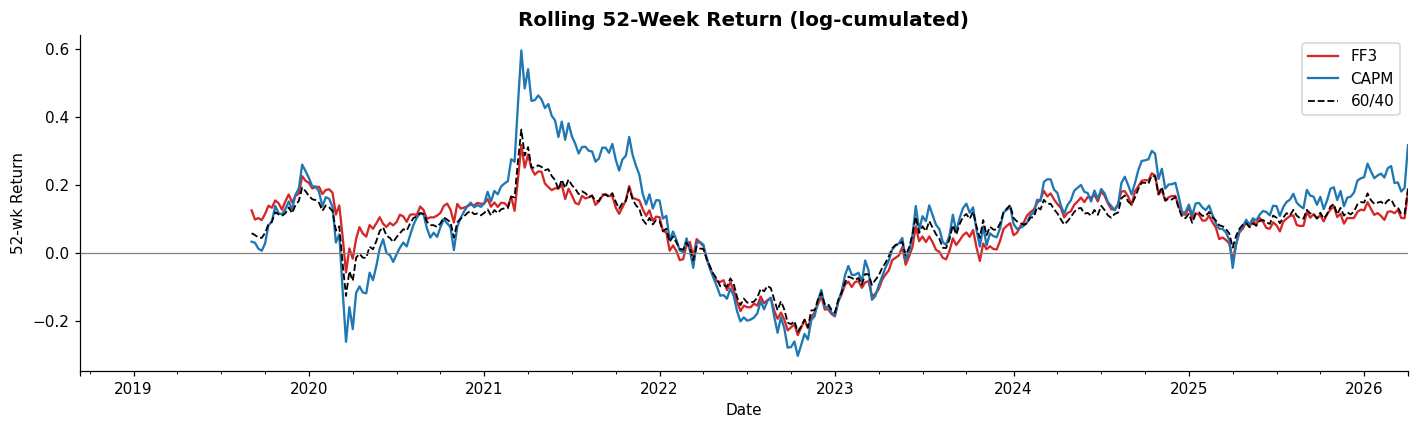

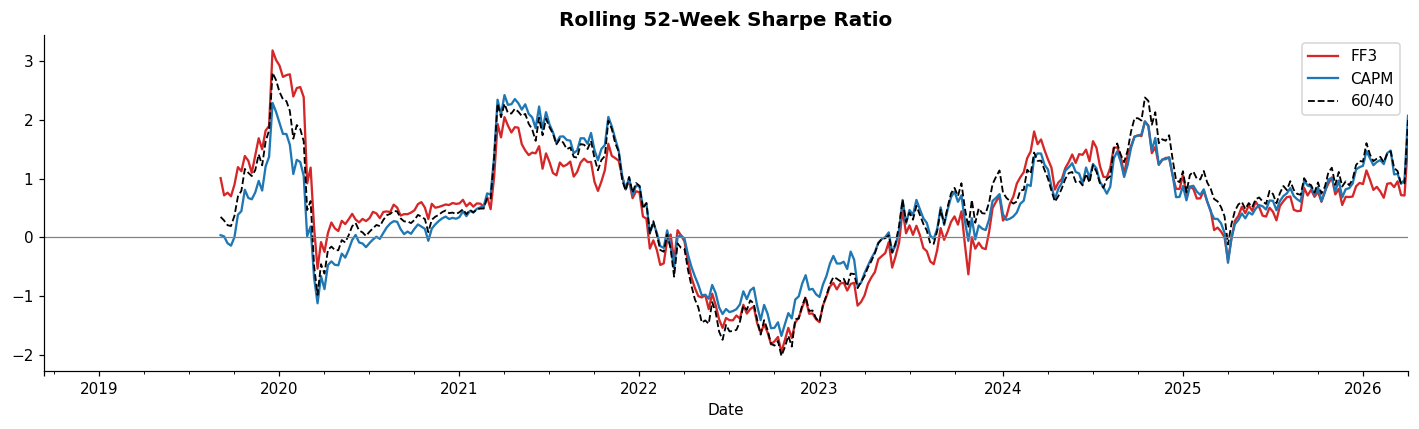

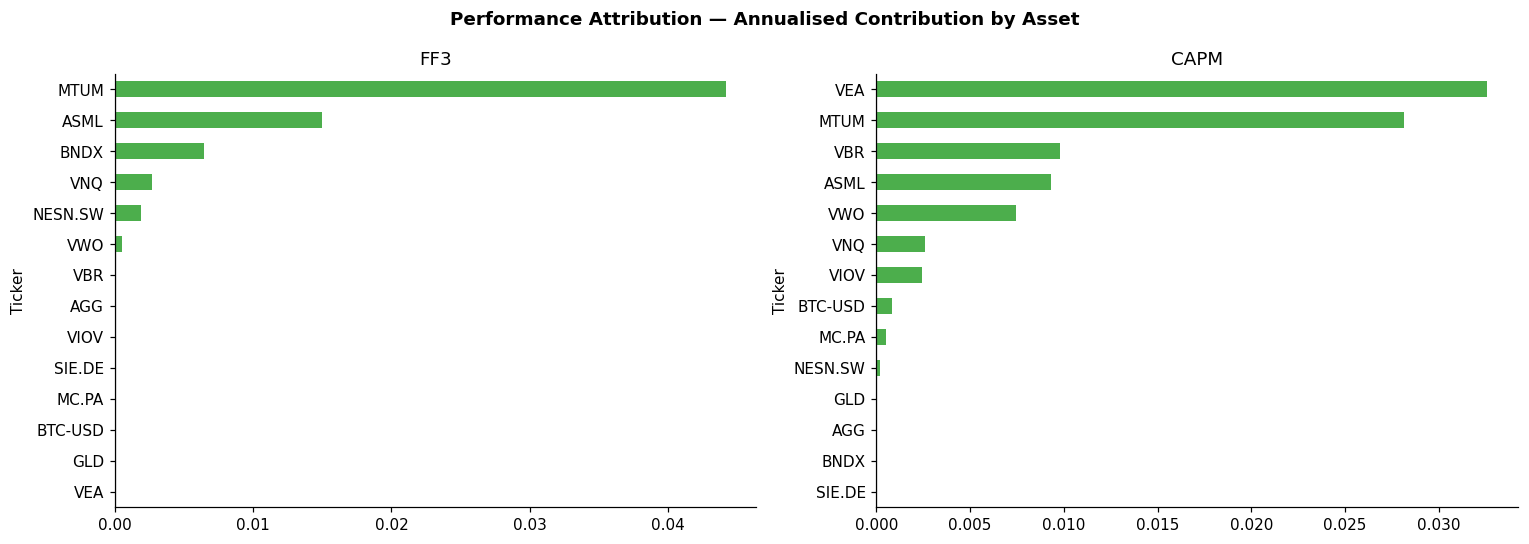

In [24]:
# ── Backtest with monthly rebalancing ─────────────────────────────────────
def backtest_rebalanced(weights, returns_df):
    parts = []
    for _, grp in returns_df.groupby(pd.Grouper(freq='ME')):
        if len(grp): parts.append((grp * weights).sum(axis=1))
    return pd.concat(parts).sort_index()

port_ff3_reb  = backtest_rebalanced(w_ff3.values,  R)
port_capm_reb = backtest_rebalanced(w_capm.values, R)

fig, ax = plt.subplots(figsize=(13, 5))
(np.exp(port_ff3_reb.cumsum())  - 1).plot(ax=ax, label='FF3 — Monthly Rebalanced', color='#d62728', lw=1.8)
(np.exp(port_ff3.cumsum())      - 1).plot(ax=ax, label='FF3 — Buy & Hold',        color='#d62728', lw=1.5, ls='--')
(np.exp(bench_6040.cumsum())    - 1).plot(ax=ax, label='60/40 Benchmark (P1)',     color='black',   lw=1.5, ls=':')
ax.set_title('Monthly Rebalanced vs Buy & Hold — FF3', fontweight='bold')
ax.set_ylabel('Cumulative Return'); ax.legend(); ax.axhline(0, color='grey', lw=0.8)
plt.tight_layout(); plt.show()

# ── Rolling 52-week return ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
(port_ff3.rolling(52).sum()).plot(ax=ax,   label='FF3',   color='#d62728', lw=1.5)
(port_capm.rolling(52).sum()).plot(ax=ax,  label='CAPM',  color='#1f77b4', lw=1.5)
(bench_6040.rolling(52).sum()).plot(ax=ax, label='60/40', color='black',   lw=1.2, ls='--')
ax.set_title('Rolling 52-Week Return (log-cumulated)', fontweight='bold', fontsize=13)
ax.set_ylabel('52-wk Return'); ax.axhline(0, color='grey', lw=0.8); ax.legend()
plt.tight_layout(); plt.show()

# ── Rolling Sharpe — FIX: 52-week window (not 252) ─────────────
def rolling_sr(s, rf, w=52):
    return (s.rolling(w).mean() * 52 - rf) / (s.rolling(w).std() * np.sqrt(52))

fig, ax = plt.subplots(figsize=(13, 4))
rolling_sr(port_ff3,   rf_annual).plot(ax=ax, label='FF3',         color='#d62728', lw=1.5)
rolling_sr(port_capm,  rf_annual).plot(ax=ax, label='CAPM',        color='#1f77b4', lw=1.5)
rolling_sr(bench_6040, rf_annual).plot(ax=ax, label='60/40',       color='black',   lw=1.2, ls='--')
ax.axhline(0, color='grey', lw=0.8)
ax.set_title('Rolling 52-Week Sharpe Ratio', fontweight='bold', fontsize=13)
ax.legend(); plt.tight_layout(); plt.show()

# ── Performance attribution ───────────────────────────────────────────────
contrib_ff3  = (R * w_ff3.values).mean()  * 52
contrib_capm = (R * w_capm.values).mean() * 52
contrib_df   = pd.DataFrame({'FF3': contrib_ff3, 'CAPM': contrib_capm}).sort_values('FF3')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Performance Attribution — Annualised Contribution by Asset', fontweight='bold')
for ax, (col, color) in zip(axes, [('FF3', '#d62728'), ('CAPM', '#1f77b4')]):
    c_sorted = contrib_df[col].sort_values()
    bar_c    = ['#d62728' if v < 0 else '#2ca02c' for v in c_sorted]
    c_sorted.plot(kind='barh', ax=ax, color=bar_c, alpha=0.85)
    ax.axvline(0, color='grey', lw=0.8); ax.set_title(col)
plt.tight_layout(); plt.show()

In [25]:
# ── Advanced metrics: Information Ratio, Tracking Error, Jensen Alpha ────
def advanced_metrics(port_ret, bench_ret, rf_ann, label):
    ann_r  = port_ret.mean() * 52
    ann_v  = port_ret.std()  * np.sqrt(52)
    active = (port_ret - bench_ret).dropna()
    te     = active.std() * np.sqrt(52)
    ir     = active.mean() * 52 / te if te > 0 else np.nan
    # Jensen Alpha: regression on benchmark
    slope, intercept, _, _, _ = sp_stats.linregress(bench_ret, port_ret)
    jensen = (1 + intercept)**52 - 1  # annualised (compounding)
    return pd.Series({
        'Return': ann_r, 'Volatility': ann_v,
        'Tracking Error': te, 'Information Ratio': ir, 'Jensen Alpha': jensen
    }, name=label)

adv = pd.concat([
    advanced_metrics(port_ff3,  bench_6040, rf_annual, 'FF3'),
    advanced_metrics(port_capm, bench_6040, rf_annual, 'CAPM'),
    advanced_metrics(port_ew,   bench_6040, rf_annual, 'EW'),
], axis=1)
print('=== Advanced Metrics vs 60/40 Benchmark ===\n')
print(adv.round(4))

=== Advanced Metrics vs 60/40 Benchmark ===

                      FF3    CAPM      EW
Return             0.0707  0.0938  0.1068
Volatility         0.1236  0.1898  0.1600
Tracking Error     0.0484  0.0802  0.0693
Information Ratio  0.0100  0.2942  0.5286
Jensen Alpha       0.0025 -0.0168  0.0188


## 8. Glide Path Simulation

Systematic reduction of equity exposure from **~80% → 60%** over the last 10 years of the backtest (Sofia: age 57 → 67).


CAPM equity allocation at Glide Path start: 68.0%


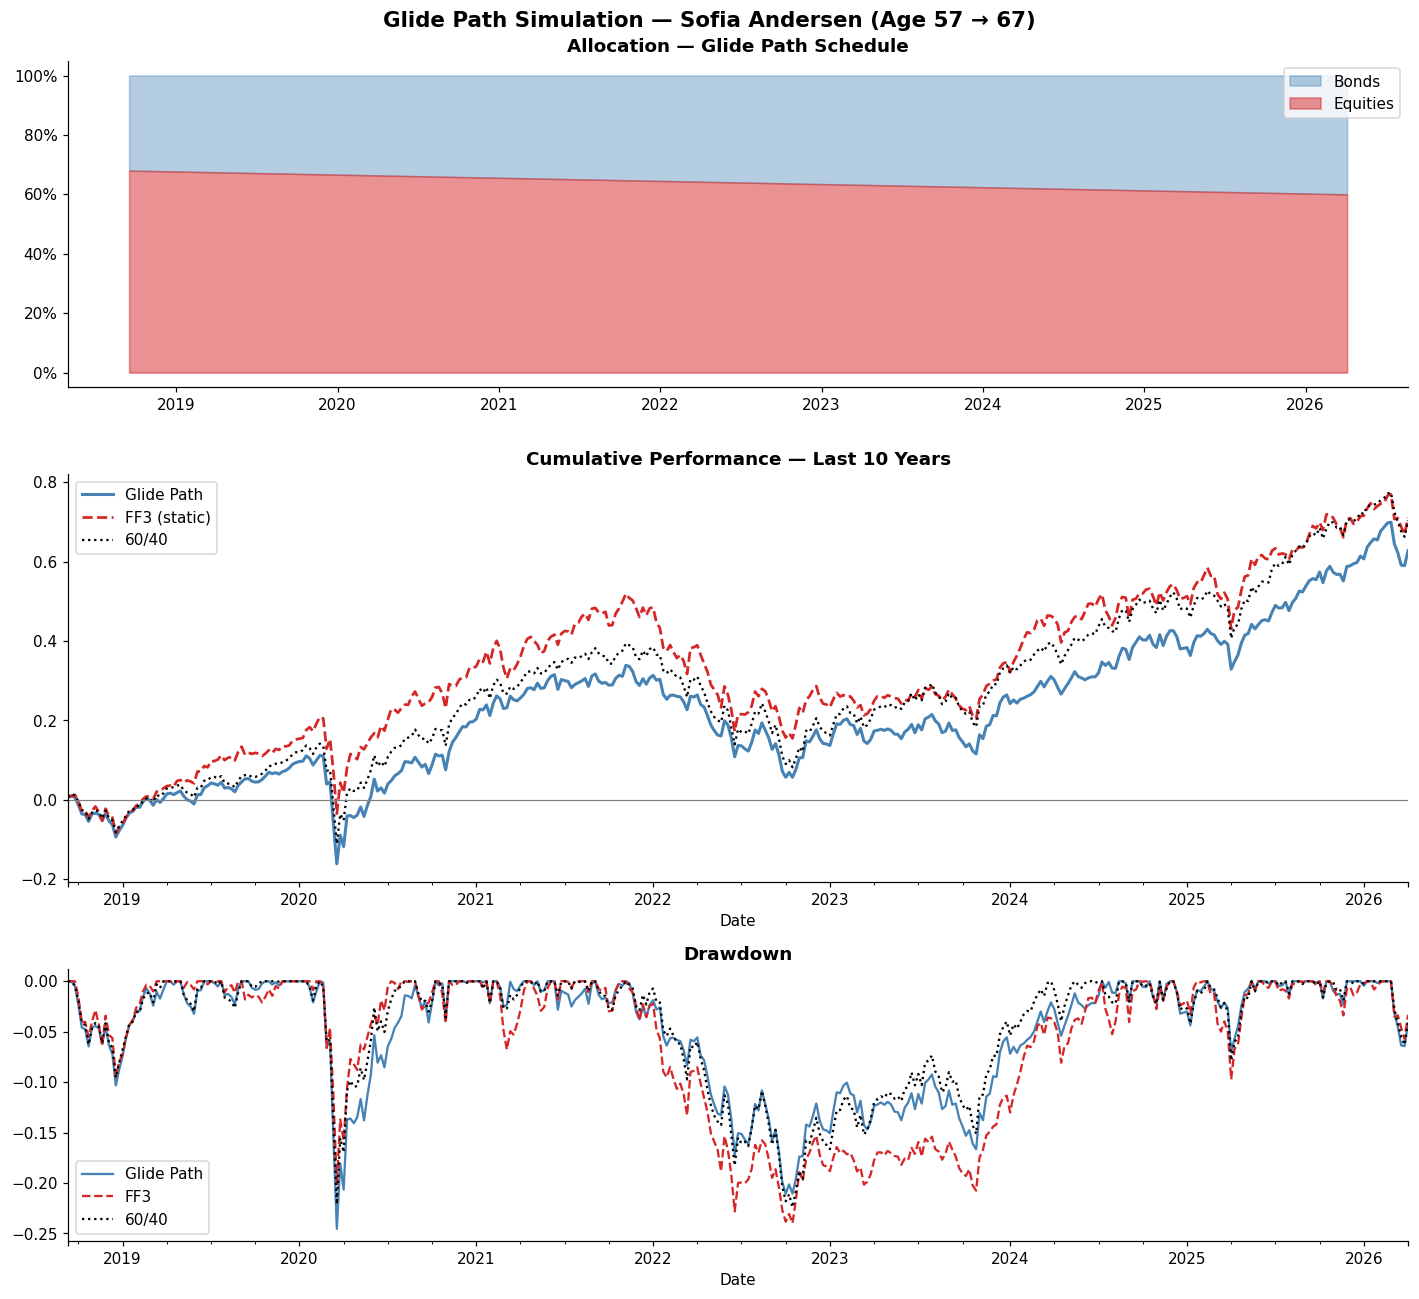


Glide Path — Annualised Return   : 6.41%
Glide Path — Volatility           : 12.43%
Glide Path — Sharpe               : 0.290
Glide Path — Sortino              : 0.344
Glide Path — Max Drawdown         : -24.54%
Starting allocation: 68.0%  →  ending: 60.0%


In [26]:
# ── Glide Path backtest ──────────────────────────────────────────────────────
# ── P3 weights — defined here for use in both Glide Path (S.8) and Comparison (S.10) ──
P3_TICKERS = ['VIOV', 'MTUM', 'VBR', 'VEA', 'VWO', 'AGG', 'BNDX', 'GLD', 'VNQ']
w_p3_etf = pd.Series({
    'VIOV': 0.12, 'MTUM': 0.11, 'VBR':  0.10,
    'VEA':  0.15, 'VWO':  0.08,
    'AGG':  0.15, 'BNDX': 0.12,
    'GLD':  0.08, 'VNQ':  0.04,
})
W_BIL = 0.05  # hard constraint (Sofia)

gp_start = R.index[-1] - pd.DateOffset(years=10)
gp_dates = R.index[R.index >= gp_start]
n_weeks  = len(gp_dates)

BOND_ASSETS   = ['AGG', 'BNDX']
# Glide Path: use P3_TICKERS (actual P3 scope), not PORTFOLIO_TICKERS
# PORTFOLIO_TICKERS includes BTC-USD and individual stocks excluded from P3
P3_TICKERS_GLIDE = ['VIOV', 'MTUM', 'VBR', 'VEA', 'VWO', 'AGG', 'BNDX', 'GLD', 'VNQ']
EQUITY_ASSETS = [t for t in P3_TICKERS_GLIDE if t not in BOND_ASSETS]

# Starting point: effective equity allocation from CAPM model
eq_share_start = w_p3_etf[[t for t in EQUITY_ASSETS if t in w_p3_etf.index]].sum()
print(f'CAPM equity allocation at Glide Path start: {eq_share_start:.1%}')

# Linear reduction towards 60%
eq_alloc_gp   = np.linspace(float(eq_share_start), 0.60, n_weeks)
bond_alloc_gp = 1 - eq_alloc_gp

# Normalised sleeves
w_eq_norm   = w_p3_etf[[t for t in EQUITY_ASSETS if t in w_p3_etf.index]]
w_eq_norm   = w_eq_norm / w_eq_norm.sum()
w_bond_norm = w_p3_etf[[t for t in BOND_ASSETS if t in w_p3_etf.index]]
w_bond_norm = w_bond_norm / w_bond_norm.sum() if w_bond_norm.sum() > 0 else pd.Series({t: 1/len(BOND_ASSETS) for t in BOND_ASSETS})

R_gp     = R.loc[gp_dates]
ret_eq   = (R_gp[EQUITY_ASSETS] * w_eq_norm.values).sum(axis=1).values
ret_bond = (R_gp[BOND_ASSETS]   * w_bond_norm.values).sum(axis=1).values

gp_returns = pd.Series(eq_alloc_gp * ret_eq + bond_alloc_gp * ret_bond,
                        index=gp_dates, name='Glide Path')

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 12), gridspec_kw={'height_ratios': [1.2, 1.5, 1]})
fig.suptitle('Glide Path Simulation — Sofia Andersen (Age 57 → 67)', fontweight='bold', fontsize=14)

axes[0].fill_between(gp_dates, eq_alloc_gp, 1, alpha=0.40, color='steelblue', label='Bonds')
axes[0].fill_between(gp_dates, 0, eq_alloc_gp,  alpha=0.50, color='#d62728',   label='Equities')
axes[0].set_title('Allocation — Glide Path Schedule', fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[0].legend(loc='upper right')

(np.exp(gp_returns.cumsum()) - 1).plot(ax=axes[1], label='Glide Path', color='steelblue', lw=2)
(np.exp(port_ff3.loc[gp_dates].cumsum()) - 1).plot(ax=axes[1], label='FF3 (static)', color='#d62728', lw=1.8, ls='--')
(np.exp(bench_6040.loc[gp_dates].cumsum()) - 1).plot(ax=axes[1], label='60/40', color='black', lw=1.5, ls=':')
axes[1].set_title('Cumulative Performance — Last 10 Years', fontweight='bold')
axes[1].axhline(0, color='grey', lw=0.8); axes[1].legend()

for port, label, color, ls in [
    (gp_returns, 'Glide Path', 'steelblue', '-'),
    (port_ff3.loc[gp_dates], 'FF3', '#d62728', '--'),
    (bench_6040.loc[gp_dates], '60/40', 'black', ':'),
]:
    cum = np.exp(port.cumsum())
    (cum / cum.cummax() - 1).plot(ax=axes[2], label=label, color=color, lw=1.5, ls=ls)
axes[2].set_title('Drawdown', fontweight='bold'); axes[2].legend()
plt.tight_layout(); plt.show()

# ── Glide Path metrics — FIX: annualisation ×52 (weekly) ───────────
gp_ann_ret = gp_returns.mean() * 52
gp_ann_vol = gp_returns.std()  * np.sqrt(52)
gp_cum     = np.exp(gp_returns.cumsum())
gp_dd      = (gp_cum / gp_cum.cummax() - 1).min()
gp_sr      = (gp_ann_ret - rf_annual) / gp_ann_vol
down_gp    = gp_returns[gp_returns < 0].std() * np.sqrt(52)
gp_sortino = (gp_ann_ret - rf_annual) / down_gp

print(f'\nGlide Path — Annualised Return   : {gp_ann_ret:.2%}')
print(f'Glide Path — Volatility           : {gp_ann_vol:.2%}')
print(f'Glide Path — Sharpe               : {gp_sr:.3f}')
print(f'Glide Path — Sortino              : {gp_sortino:.3f}')
print(f'Glide Path — Max Drawdown         : {gp_dd:.2%}')
print(f'Starting allocation: {eq_alloc_gp[0]:.1%}  →  ending: {eq_alloc_gp[-1]:.1%}')

## 9. Asynchronous Trading Adjustment

US, European, and Asian markets do not close simultaneously. Correlations computed on **daily** data underestimate true cross-asset dependencies. Solution: **weekly returns** (Friday-to-Friday close) — already applied throughout this notebook.


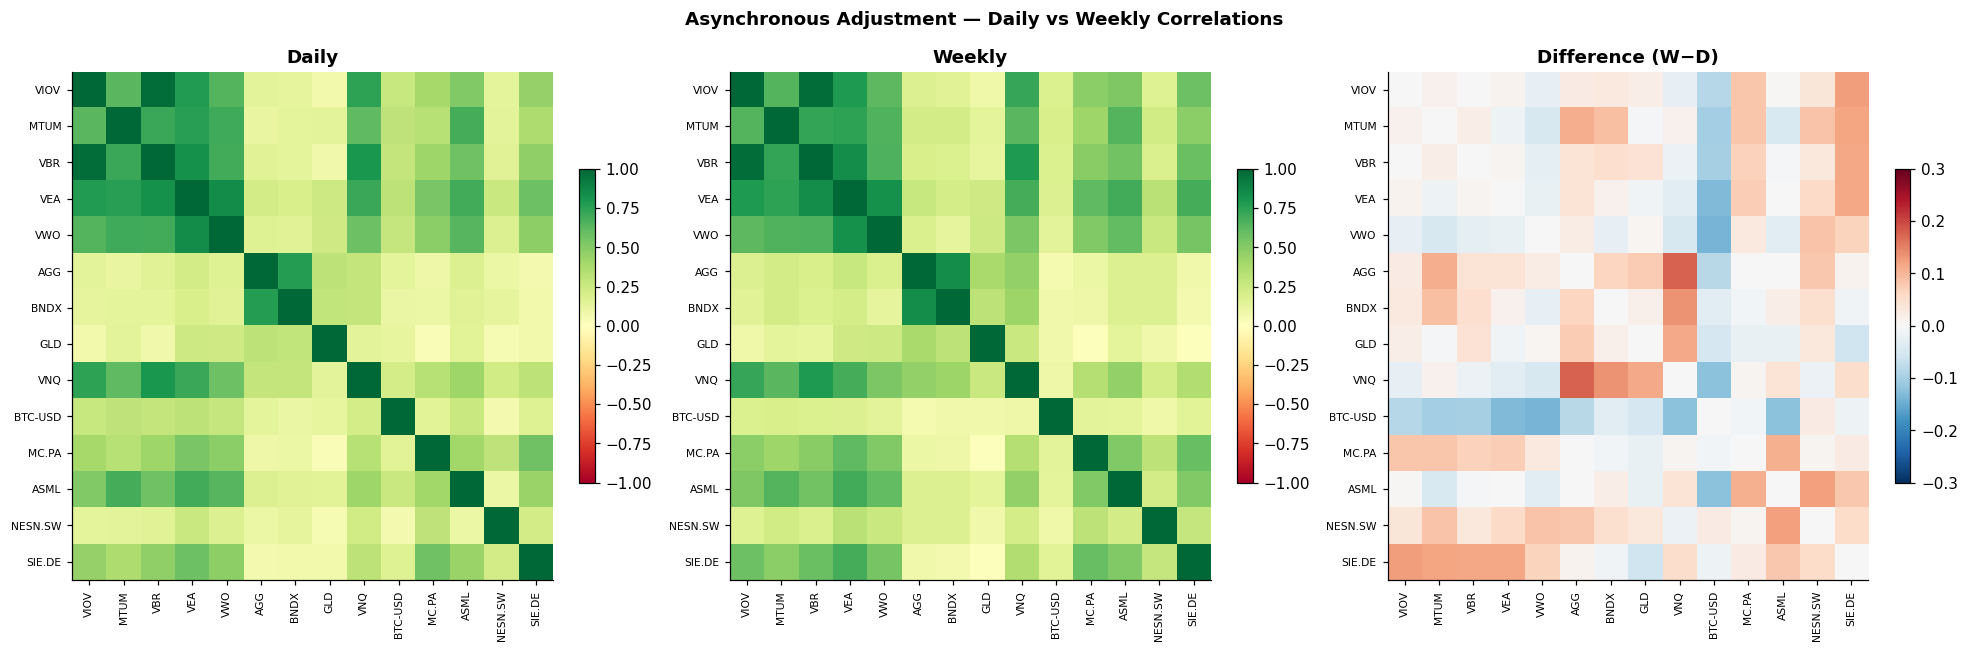


=== Impact on cross-region correlations ===
Pair                            Daily         Weekly        Δ
VIOV / MC.PA                    0.397          0.480    0.083
MTUM / ASML                     0.687          0.641   -0.045
VBR / NESN.SW                   0.157          0.188    0.031
VEA / VWO                       0.845          0.823   -0.022


In [27]:
# Resample to weekly (Friday close)
weekly_prices_fri  = prices.resample('W-FRI').last()
weekly_returns_fri = np.log(weekly_prices_fri / weekly_prices_fri.shift(1)).dropna()

# Daily correlations (from raw daily prices, for valid comparison)
daily_returns_raw = np.log(prices_raw[PORTFOLIO_TICKERS] / prices_raw[PORTFOLIO_TICKERS].shift(1)).dropna()
daily_corr  = daily_returns_raw.corr()
weekly_corr = weekly_returns_fri.corr()
diff_corr   = weekly_corr - daily_corr

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Asynchronous Adjustment — Daily vs Weekly Correlations', fontsize=12, fontweight='bold')
for ax, (mat, title, vmin, vmax, cmap) in zip(axes, [
    (daily_corr,  'Daily',      -1,    1,   'RdYlGn'),
    (weekly_corr, 'Weekly',     -1,    1,   'RdYlGn'),
    (diff_corr,   'Difference (W−D)', -0.3,  0.3, 'RdBu_r'),
]):
    im = ax.imshow(mat.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(PORTFOLIO_TICKERS)))
    ax.set_yticks(range(len(PORTFOLIO_TICKERS)))
    ax.set_xticklabels(mat.columns, rotation=90, fontsize=7)
    ax.set_yticklabels(mat.index, fontsize=7)
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout(); plt.show()

# Impact sur les paires cross-régions
cross_pairs = [('VIOV', 'MC.PA'), ('MTUM', 'ASML'), ('VBR', 'NESN.SW'), ('VEA', 'VWO')]
print('\n=== Impact on cross-region correlations ===')
print(f'{"Pair":<22} {"Daily":>14} {"Weekly":>14} {"Δ":>8}')
for a, b in cross_pairs:
    if a in daily_corr.columns and b in daily_corr.columns:
        d = daily_corr.loc[a, b]; w = weekly_corr.loc[a, b]
        print(f'{a+" / "+b:<22} {d:>14.3f} {w:>14.3f} {w-d:>8.3f}')


STRESS TESTING — PORTFOLIO RESILIENCE

2020 COVID Crash (2020-02-01 → 2020-05-31)
  FF3  : return= -2.19%  |  vol=32.17%
  CAPM : return=-13.59%
  60/40: return= -5.08%  |  vol=32.77%

2022 Rate Hike Cycle (2022-01-01 → 2022-09-30)
  FF3  : return=-23.29%  |  vol=14.99%
  CAPM : return=-28.10%
  60/40: return=-21.73%  |  vol=13.92%


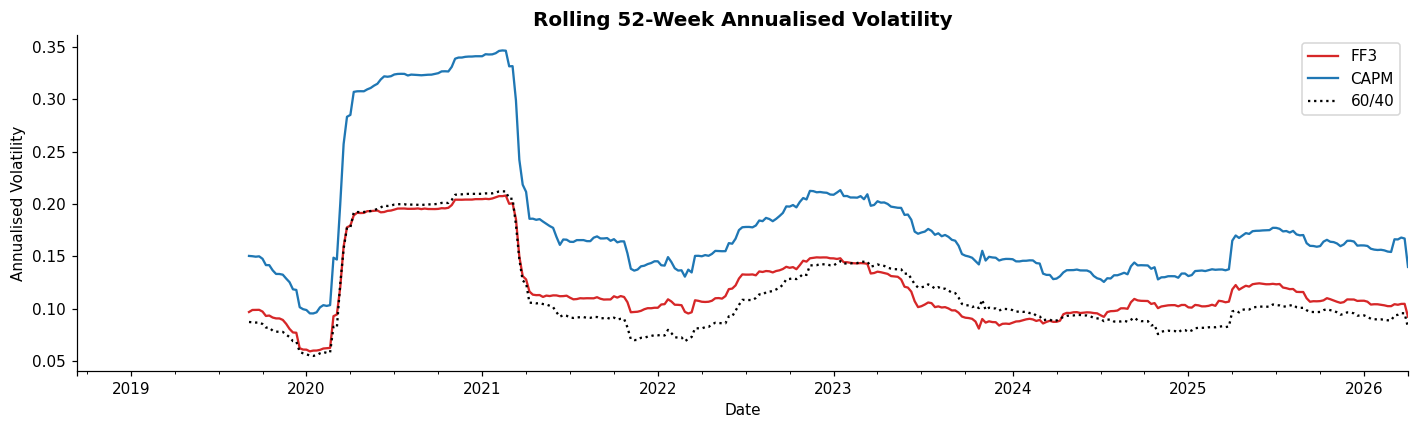

In [28]:
# ── Stress Testing ───────────────────────────────────────────────────────────
stress_periods = [
    {'name': '2020 COVID Crash',   'start': '2020-02-01', 'end': '2020-05-31'},
    {'name': '2022 Rate Hike Cycle','start': '2022-01-01', 'end': '2022-09-30'},
]

print('\n' + '='*80)
print('STRESS TESTING — PORTFOLIO RESILIENCE')
print('='*80)
for period in stress_periods:
    mask = (port_ff3.index >= period['start']) & (port_ff3.index <= period['end'])
    if mask.sum() == 0:
        print(f"\n{period['name']}: period outside data range"); continue
    r_ff3_s  = port_ff3[mask].sum()
    r_capm_s = port_capm[mask].sum()
    r_b_s    = bench_6040[mask].sum()
    v_ff3_s  = port_ff3[mask].std()  * np.sqrt(52)
    v_b_s    = bench_6040[mask].std() * np.sqrt(52)
    print(f"\n{period['name']} ({period['start']} → {period['end']})")
    print(f"  FF3  : return={r_ff3_s*100:6.2f}%  |  vol={v_ff3_s*100:.2f}%")
    print(f"  CAPM : return={r_capm_s*100:6.2f}%")
    print(f"  60/40: return={r_b_s*100:6.2f}%  |  vol={v_b_s*100:.2f}%")

# ── Rolling Volatility ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
for port, label, color, ls in [
    (port_ff3,   'FF3',   '#d62728', '-'),
    (port_capm,  'CAPM',  '#1f77b4', '-'),
    (bench_6040, '60/40', 'black',   ':'),
]:
    (port.rolling(52).std() * np.sqrt(52)).plot(ax=ax, label=label, color=color, lw=1.5, ls=ls)
ax.set_title('Rolling 52-Week Annualised Volatility', fontweight='bold', fontsize=13)
ax.set_ylabel('Annualised Volatility'); ax.legend()
plt.tight_layout(); plt.show()

## 10. Three Portfolio Comparison (P1 / P2 / P3)

- **P1**: 60/40 Benchmark (VT + AGG)
- **P2**: US Equity Style-Tilted (VIOV / MTUM / VBR, equal-weight)
- **P3**: Global Multi-Asset (Sofia recommended, 10 assets + 5% BIL cash)


In [29]:
import matplotlib.pyplot as plt

# ── P1: 60/40 Benchmark ─────────────────────────────────────────────────────
p1_ret = bench_6040.mean() * 52
p1_vol = bench_6040.std()  * np.sqrt(52)
p1_sharpe = (p1_ret - rf_annual) / p1_vol
p1_cum = np.exp(bench_6040.cumsum()) - 1
p1_dd  = (np.exp(bench_6040.cumsum()) / np.exp(bench_6040.cumsum()).cummax() - 1).min()
p1_calmar = p1_ret / abs(p1_dd)
p1_down   = bench_6040[bench_6040 < 0].std() * np.sqrt(52)
p1_sortino = (p1_ret - rf_annual) / p1_down

# ── P2: US Equity Equal-Weight ──────────────────────────────────────────────
p2_series = (R[US_EQUITY] * w_us_fixed.values).sum(axis=1)
p2_ret     = p2_series.mean() * 52
p2_vol     = p2_series.std()  * np.sqrt(52)
p2_sharpe  = (p2_ret - rf_annual) / p2_vol
p2_cum     = np.exp(p2_series.cumsum()) - 1
p2_dd      = (np.exp(p2_series.cumsum()) / np.exp(p2_series.cumsum()).cummax() - 1).min()
p2_calmar  = p2_ret / abs(p2_dd)
p2_down    = p2_series[p2_series < 0].std() * np.sqrt(52)
p2_sortino = (p2_ret - rf_annual) / p2_down

# ── P3: Global Multi-Asset (with BIL) ───────────────────────────────────────
# P3_TICKERS, w_p3_etf, W_BIL defined in Section 8 (Glide Path)

# FIX: BIL correctly added into P3 return calculation
p3_etf_ret = (R[P3_TICKERS] * w_p3_etf.values).sum(axis=1)
p3_series  = (1 - W_BIL) * p3_etf_ret + W_BIL * bil_weekly
p3_series  = p3_series.dropna()

# Monthly rebalancing for P3
def backtest_rebal_p3(r_etf, r_bil, w_etf, w_bil, returns_df_etf):
    parts = []
    for _, grp in returns_df_etf.groupby(pd.Grouper(freq='ME')):
        if len(grp):
            bil_grp = r_bil.reindex(grp.index).fillna(0)
            parts.append((grp * w_etf.values).sum(axis=1) * (1 - w_bil) + bil_grp * w_bil)
    return pd.concat(parts).sort_index()

p3_reb = backtest_rebal_p3(p3_etf_ret, bil_weekly, w_p3_etf, W_BIL, R[P3_TICKERS])

p3_ret     = p3_series.mean() * 52
p3_vol     = p3_series.std()  * np.sqrt(52)
p3_sharpe  = (p3_ret - rf_annual) / p3_vol
p3_cum     = np.exp(p3_series.cumsum()) - 1
p3_dd      = (np.exp(p3_series.cumsum()) / np.exp(p3_series.cumsum()).cummax() - 1).min()
p3_calmar  = p3_ret / abs(p3_dd)
p3_down    = p3_series[p3_series < 0].std() * np.sqrt(52)
p3_sortino = (p3_ret - rf_annual) / p3_down

# ── Summary table ─────────────────────────────────────────────────────
summary = pd.DataFrame({
    'P1 — 60/40 Benchmark':    [2, '60%', '40%', f'{p1_ret:.2%}', f'{p1_vol:.2%}', f'{p1_sharpe:.2f}', f'{p1_sortino:.2f}', f'{p1_dd:.2%}', f'{p1_calmar:.2f}'],
    'P2 — US Equity Tilted':   [3, '100%', '0%', f'{p2_ret:.2%}', f'{p2_vol:.2%}', f'{p2_sharpe:.2f}', f'{p2_sortino:.2f}', f'{p2_dd:.2%}', f'{p2_calmar:.2f}'],
    'P3 — Global Multi-Asset': [10, '~61%', '~34%', f'{p3_ret:.2%}', f'{p3_vol:.2%}', f'{p3_sharpe:.2f}', f'{p3_sortino:.2f}', f'{p3_dd:.2%}', f'{p3_calmar:.2f}'],
}, index=['No. Assets','Equities','Bonds','Return','Volatility','Sharpe','Sortino','Max DD','Calmar'])

print('\n' + '='*80)
print('THREE PORTFOLIO COMPARISON')
print('='*80)
print(summary.to_string())
print('='*80)


THREE PORTFOLIO COMPARISON
           P1 — 60/40 Benchmark P2 — US Equity Tilted P3 — Global Multi-Asset
No. Assets                    2                     3                      10
Equities                    60%                  100%                    ~61%
Bonds                       40%                    0%                    ~34%
Return                    7.02%                 8.40%                   6.51%
Volatility               11.72%                22.49%                  12.16%
Sharpe                     0.36                  0.25                    0.30
Sortino                    0.44                  0.30                    0.36
Max DD                  -22.41%               -39.08%                 -23.76%
Calmar                     0.31                  0.21                    0.27


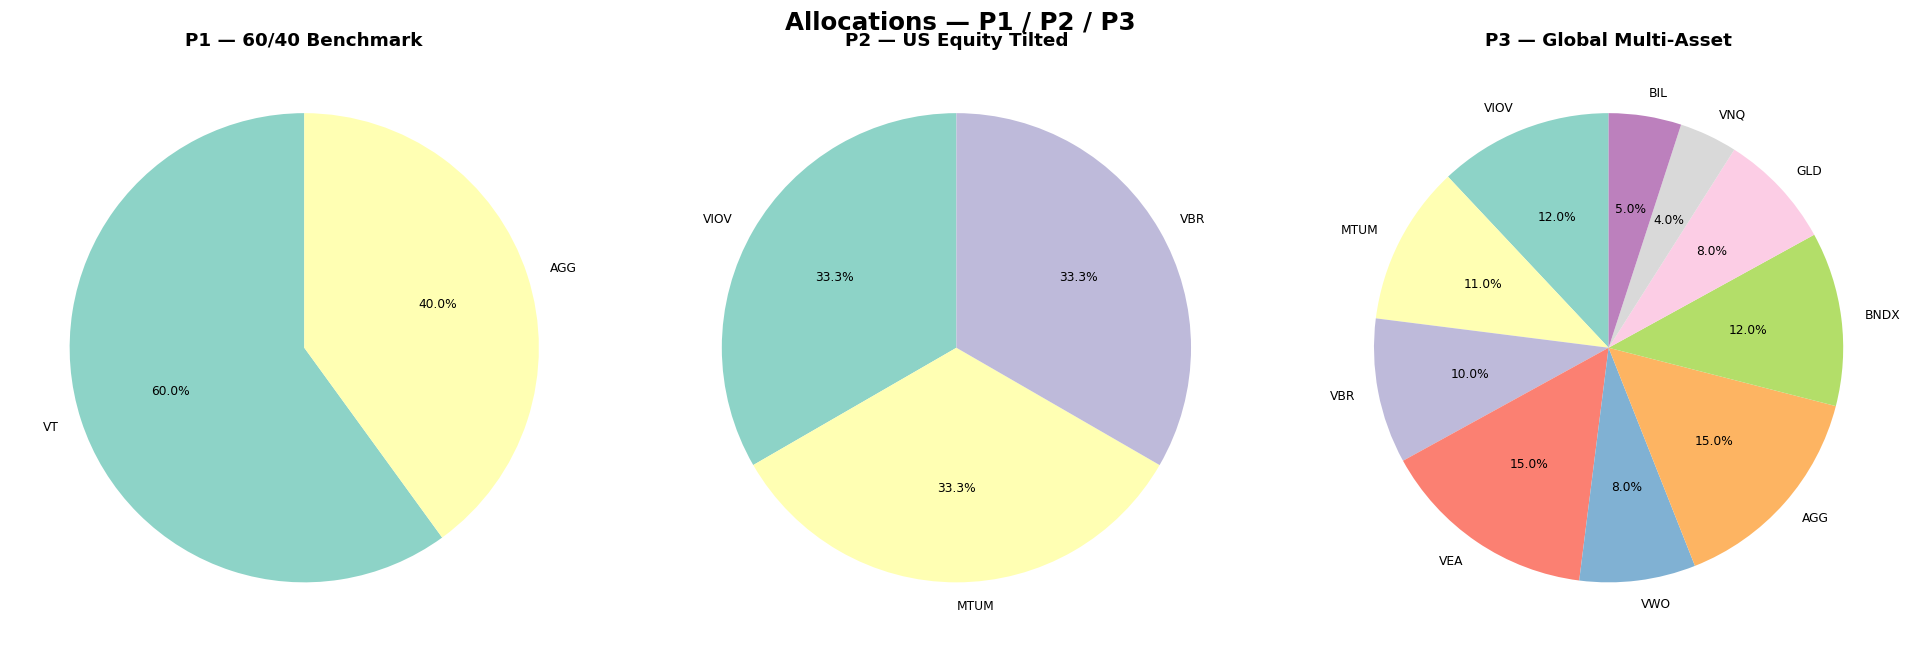

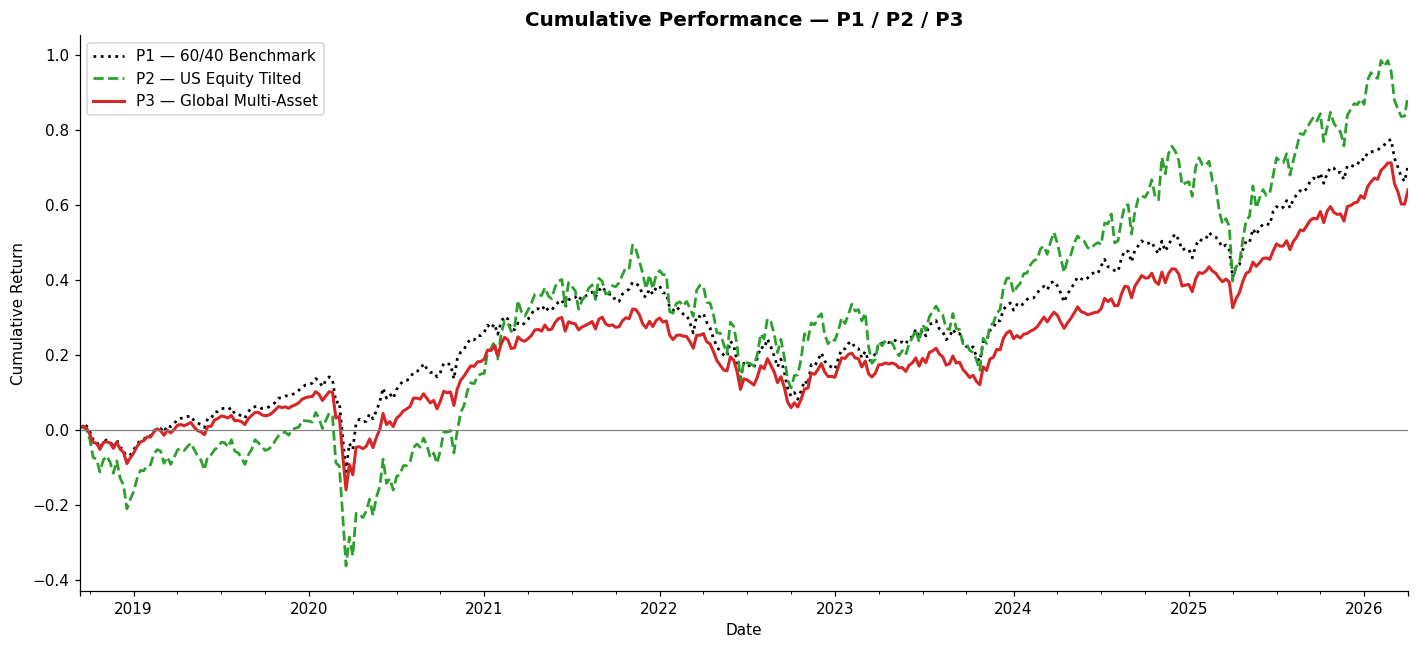

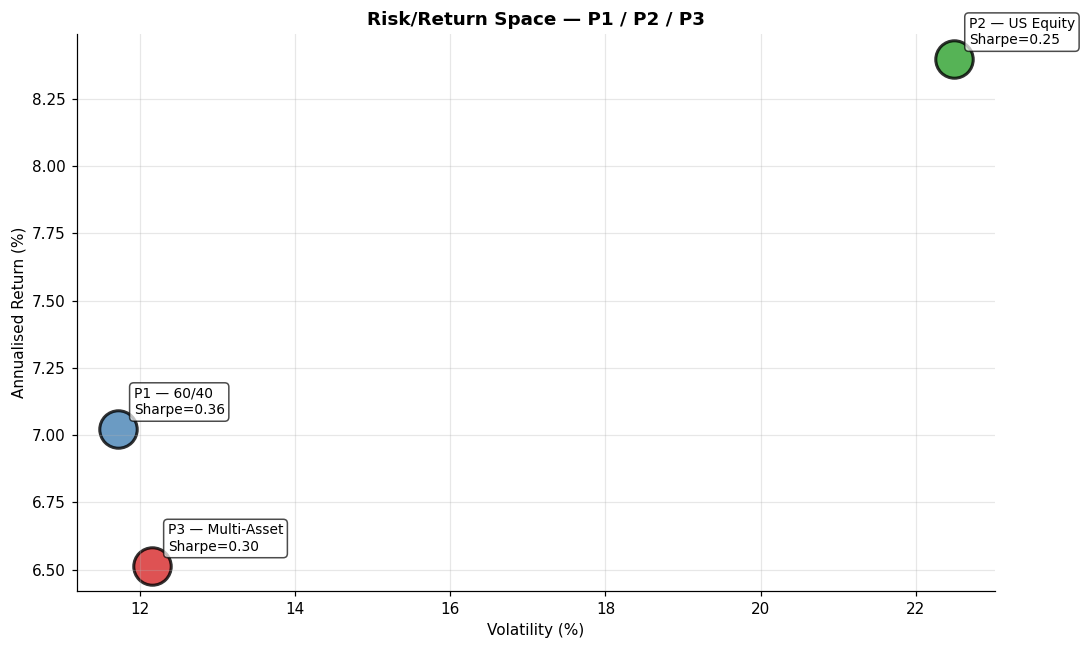

In [30]:
# ── Allocation pie charts ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Allocations — P1 / P2 / P3', fontsize=16, fontweight='bold')
colors_pal = plt.cm.Set3(np.linspace(0, 1, 12))

alloc_list = [
    ({'VT': 0.60, 'AGG': 0.40},                               'P1 — 60/40 Benchmark'),
    ({'VIOV': 1/3, 'MTUM': 1/3, 'VBR': 1/3},                 'P2 — US Equity Tilted'),
    ({**dict(w_p3_etf), 'BIL': W_BIL},                        'P3 — Global Multi-Asset'),
]

for ax, (alloc_dict, title) in zip(axes, alloc_list):
    labels  = list(alloc_dict.keys())
    weights = list(alloc_dict.values())
    ax.pie(weights, labels=labels, autopct='%1.1f%%', startangle=90,
           colors=colors_pal[:len(labels)], textprops={'fontsize': 8})
    ax.set_title(title, fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Cumulative performance P1 vs P2 vs P3 ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
p1_cum.plot(ax=ax, label='P1 — 60/40 Benchmark',    color='black',    lw=1.8, ls=':')
p2_cum.plot(ax=ax, label='P2 — US Equity Tilted',   color='#2ca02c',  lw=1.8, ls='--')
p3_cum.plot(ax=ax, label='P3 — Global Multi-Asset', color='#d62728',  lw=2.0)
ax.set_title('Cumulative Performance — P1 / P2 / P3', fontweight='bold', fontsize=13)
ax.set_ylabel('Cumulative Return'); ax.legend(fontsize=10)
ax.axhline(0, color='grey', lw=0.8); plt.tight_layout(); plt.show()

# ── Risk/return scatter ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for vol, ret, sharpe, name, color in [
    (p1_vol*100, p1_ret*100, p1_sharpe, 'P1 — 60/40',      'steelblue'),
    (p2_vol*100, p2_ret*100, p2_sharpe, 'P2 — US Equity',  '#2ca02c'),
    (p3_vol*100, p3_ret*100, p3_sharpe, 'P3 — Multi-Asset','#d62728'),
]:
    ax.scatter(vol, ret, s=600, alpha=0.8, color=color, edgecolors='black', lw=2)
    ax.annotate(
        f'{name}\nSharpe={sharpe:.2f}',
        xy=(vol, ret),
        xytext=(10, 10), textcoords='offset points', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', alpha=0.7))
ax.set_xlabel('Volatility (%)'); ax.set_ylabel('Annualised Return (%)')
ax.set_title('Risk/Return Space — P1 / P2 / P3', fontweight='bold')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 11. Scenario Analysis — 33-Year Projections (Sofia)


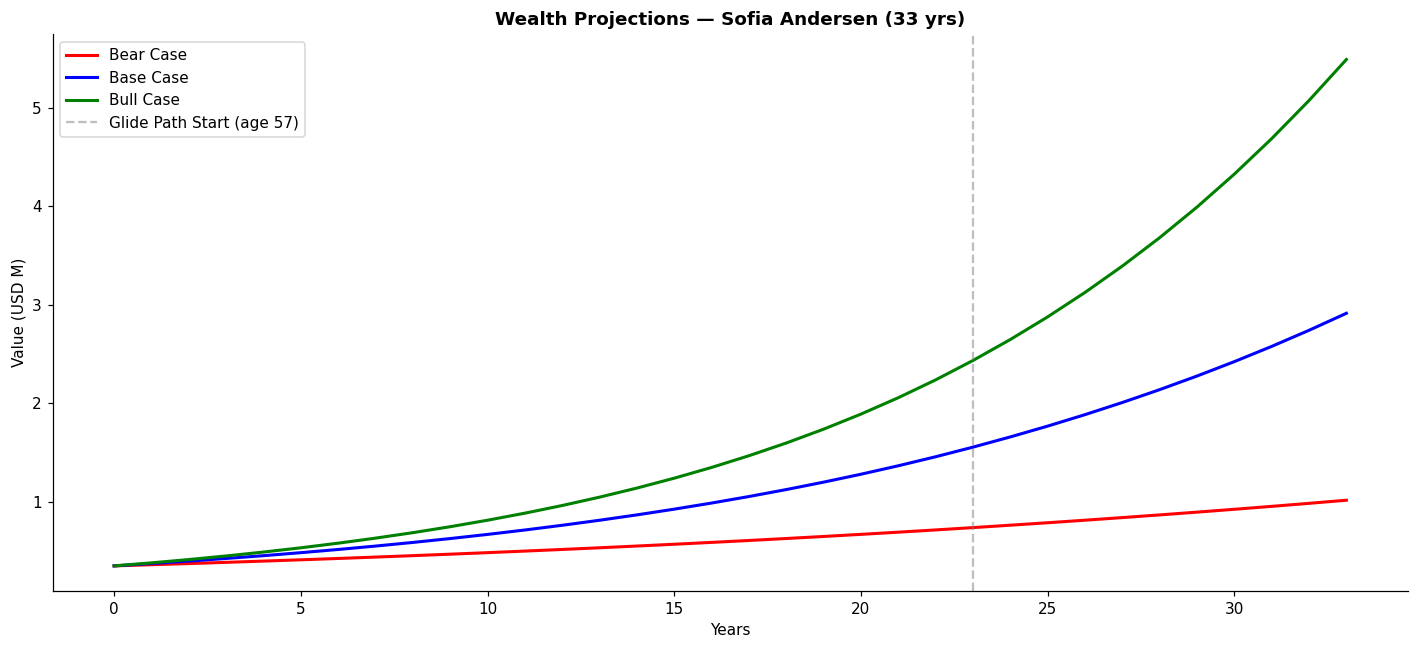

 Scenario    Portfolio        Total     Income 4%  Multiple
Bear Case 1.016402e+06 1.196402e+06  47856.084342  2.904006
Base Case 2.914255e+06 3.094255e+06 123770.210045  8.326444
Bull Case 5.490647e+06 5.670647e+06 226825.897457 15.687564


In [31]:
scenarios = {
    'Bear Case': {'description': 'Recession, high rates', 'equity_return': 0.035, 'fi_return': 0.025, 'color': 'red'},
    'Base Case': {'description': 'Normal growth',     'equity_return': 0.075, 'fi_return': 0.035, 'color': 'blue'},
    'Bull Case': {'description': 'Strong growth',       'equity_return': 0.100, 'fi_return': 0.040, 'color': 'green'},
}

fig, ax = plt.subplots(figsize=(13, 6))
scenario_results = []
for sc_name, sc in scenarios.items():
    wealth = INITIAL_INVESTMENT; path = [wealth]
    for yr in range(1, INVESTMENT_HORIZON + 1):
        eq = 0.80 if yr <= 23 else max(0.80 - 0.01 * (yr - 23), 0.60)
        ret = eq * sc['equity_return'] + (1 - eq) * sc['fi_return']
        wealth *= (1 + ret); path.append(wealth)
    ax.plot(range(INVESTMENT_HORIZON + 1), [p/1e6 for p in path],
            label=sc_name, color=sc['color'], lw=2)
    total = wealth + ASTRAZENECA_HOLDING
    scenario_results.append({'Scenario': sc_name, 'Portfolio': wealth, 'Total': total,
                              'Income 4%': total * 0.04, 'Multiple': wealth / INITIAL_INVESTMENT})

ax.set_title(f'Wealth Projections — Sofia Andersen ({INVESTMENT_HORIZON} yrs)', fontweight='bold')
ax.set_xlabel('Years'); ax.set_ylabel('Value (USD M)')
ax.axvline(23, color='grey', ls='--', alpha=0.5, label='Glide Path Start (age 57)')
ax.legend(); plt.tight_layout(); plt.show()

df_sc = pd.DataFrame(scenario_results)
print(df_sc.to_string(index=False))

## 12. Executive Summary

**Recommendation: P3 — Global Multi-Asset**

Team contributions: to be completed in the Word deliverable.


In [32]:
print('\n' + '='*80)
print('SOFIA ANDERSEN — FINAL RECOMMENDATION')
print('='*80)
print(f'  Recommended portfolio: P3 — Global Multi-Asset')
print(f'  Assets                 : 10 (ETFs + BIL cash proxy)')
print(f'  Rebalancing            : monthly')
print(f'  Cash reserve           : {W_BIL:.0%} (BIL) — Swiss residence permit constraint ✓')
print(f'  Crypto (BTC)           : 0% — below 1.5% cap (justified exclusion)')
print()
print(f'  P3 Return    : {p3_ret:.2%}   |  P1 Benchmark : {p1_ret:.2%}')
print(f'  P3 Volatility: {p3_vol:.2%}   |  P1 Benchmark : {p1_vol:.2%}')
print(f'  P3 Sharpe    : {p3_sharpe:.3f}   |  P1 Benchmark : {p1_sharpe:.3f}')
print(f'  P3 Sortino   : {p3_sortino:.3f}   |  P2 US Equity : {p2_sharpe:.3f}')
print(f'  P3 Max DD    : {p3_dd:.2%}')
print()
print(f'  Glide Path   : {GLIDE_PATH_START_AGE} yrs → {GLIDE_PATH_END_AGE} yrs | -1%/yr | target 60/40 at retirement')
print('='*80)


SOFIA ANDERSEN — FINAL RECOMMENDATION
  Recommended portfolio: P3 — Global Multi-Asset
  Assets                 : 10 (ETFs + BIL cash proxy)
  Rebalancing            : monthly
  Cash reserve           : 5% (BIL) — Swiss residence permit constraint ✓
  Crypto (BTC)           : 0% — below 1.5% cap (justified exclusion)

  P3 Return    : 6.51%   |  P1 Benchmark : 7.02%
  P3 Volatility: 12.16%   |  P1 Benchmark : 11.72%
  P3 Sharpe    : 0.305   |  P1 Benchmark : 0.359
  P3 Sortino   : 0.362   |  P2 US Equity : 0.248
  P3 Max DD    : -23.76%

  Glide Path   : 57 yrs → 67 yrs | -1%/yr | target 60/40 at retirement
